# Streamflow intermittence in transient

In [1]:

# Filter warnings (before imports)
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import pkg_resources # Must be placed after DeprecationWarning as it is itself deprecated
warnings.filterwarnings('ignore', message='.*pkg_resources.*')
warnings.filterwarnings('ignore', message='.*declare_namespace.*')

# Libraries installed by default
import sys
import glob

import os
from sys import platform
import geopandas as gpd
from datetime import datetime

# Libraries need to be installed if not
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

# # Libraries added from 'pip install' procedure
import deepdish as dd
import imageio
import hydroeval
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False
import xarray as xr
xr.set_options(keep_attrs = True)



In [2]:

from os.path import dirname, abspath
root_dir = '/home/agauvain/Git/HydroModPy'
sys.path.append(root_dir)
print("Root path directory is: {0}".format(root_dir.upper()))



Root path directory is: /HOME/AGAUVAIN/GIT/HYDROMODPY


In [3]:

# Import HydroModPy modules
from src import watershed_root
from src.watershed import climatic, geographic, geology, hydraulic, hydrography, hydrometry, intermittency, oceanic, piezometry, subbasin
from src.modeling import downslope, modflow, modpath, timeseries
from src.display import visualization_watershed, visualization_results, export_vtuvtk
from src.tools import toolbox, folder_root

fontprop = toolbox.plot_params(8,15,18,20) # small, medium, interm, large

def select_period(df, first, last):
    df = df[(df.index.year>=first) & (df.index.year<=last)]
    return df



In [4]:

example_path = os.path.join(root_dir, "examples", "04_streamflow_intermittence_in_transient/")
data_path = os.path.join(example_path, "data/")

# The folder out_path is created in the example_path root directory:
out_path = os.path.join(root_dir,'examples', 'results')
# Or define it manually
# out_path = 'C:/Simulations/HydroModPy/'

print('The results of the example will be saved here :', out_path)



The results of the example will be saved here : /home/agauvain/Git/HydroModPy/examples/results


In [5]:

dem_path = os.path.join(data_path, 'regional dem.tif')
load = True
watershed_name = 'Example_04_Nancon'
from_lib = None # os.path.join(root_dir,'watershed_library.csv')
from_dem = None # [path, cell size]
from_shp = None # [path, buffer size]
from_xyv = [389285.910, 6816518.749, 150, 10 , 'EPSG:2154'] # [x, y, snap distance, buffer size, crs proj]
bottom_path = None # path
save_object = True



In [6]:

print('##### '+watershed_name.upper()+' #####')

BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              watershed_name=watershed_name,
                              from_lib=from_lib, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=from_dem, # [path, cell size]
                              from_shp=from_shp, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              bottom_path=bottom_path, # path
                              save_object=save_object)

# Paths generated automatically but necessary for plots
stable_folder = os.path.join(out_path, watershed_name, 'results_stable')
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')



##### EXAMPLE_04_NANCON #####
      __  __          __           __  ____          ________     
     / / / /         / /          /  \/   /         / / __  /     
    / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 
   / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 
  / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  
 /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   
       /____/ Hydrological Modelling in Python /_____________/    
                                                                  
Python object was successfully loaded as requested; imported from output directory


Extract geology from specific data
Extract hydrography from specific data
Extract hydrometry from specific data
Extract intermittency from specific data
Extract subbasin from specific data


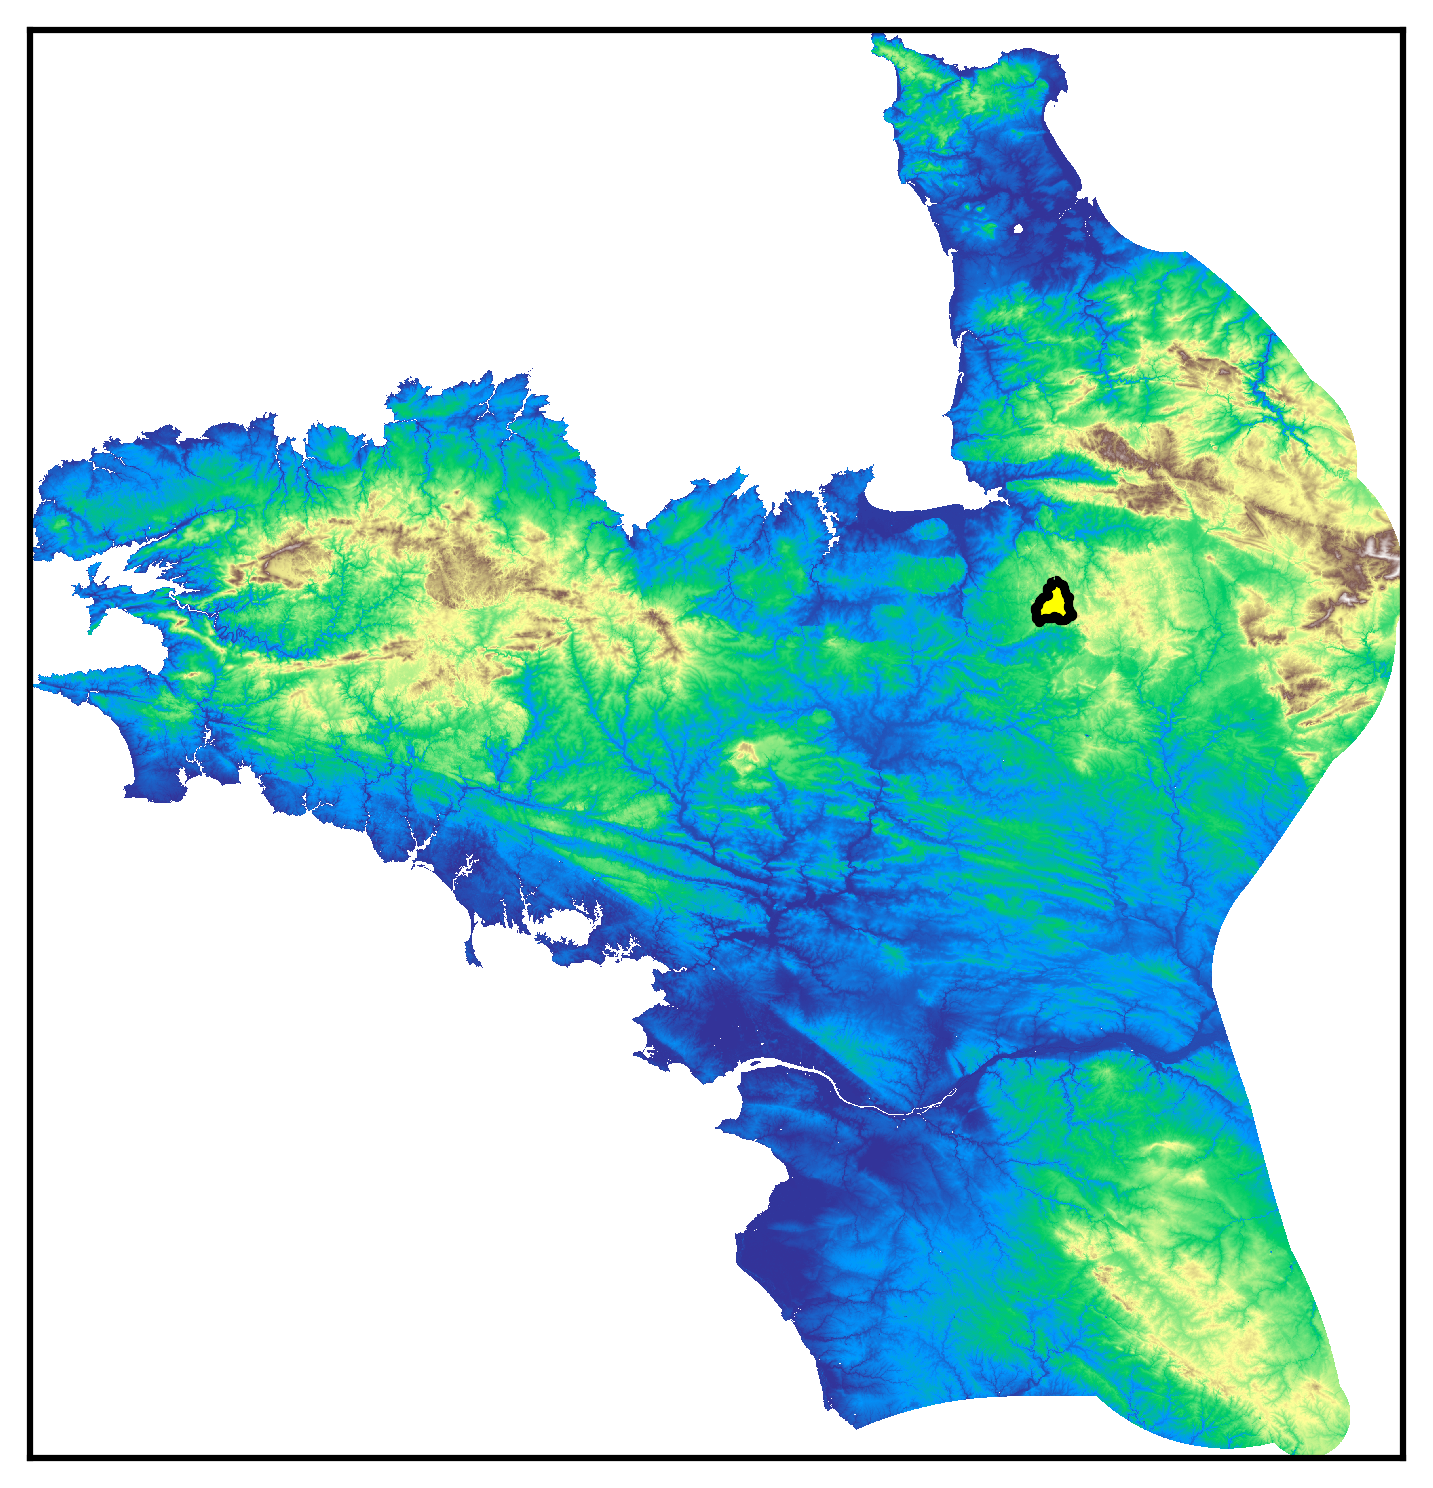

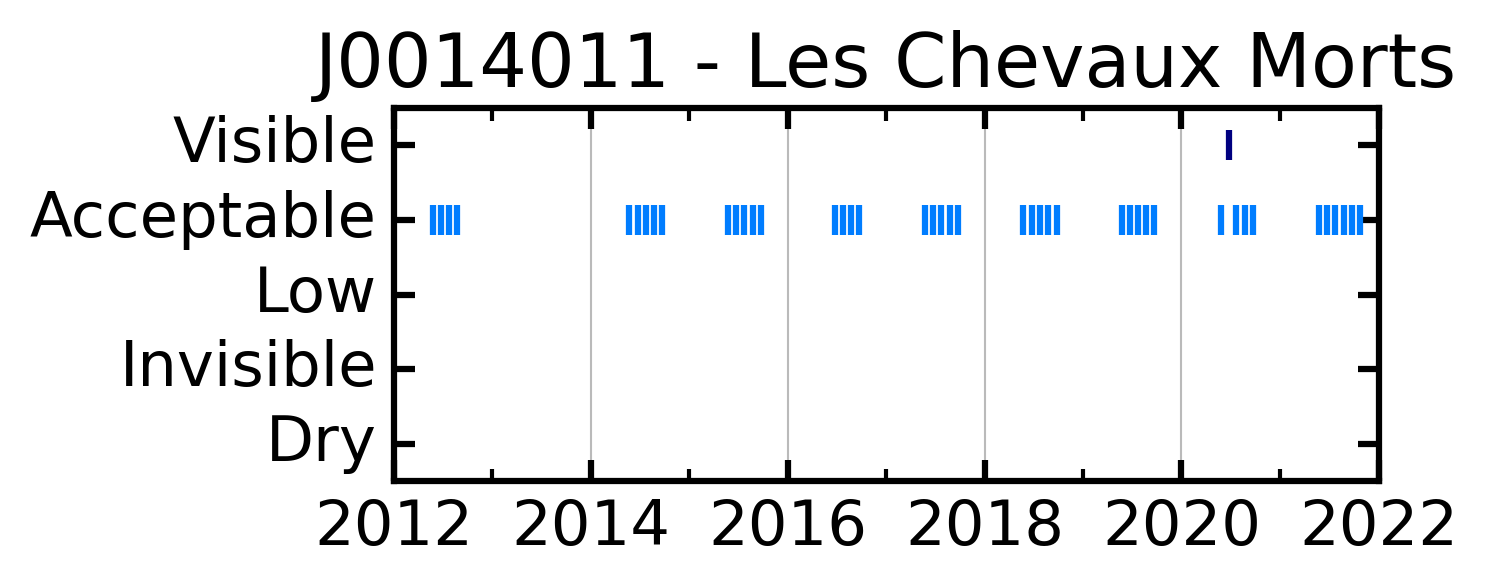

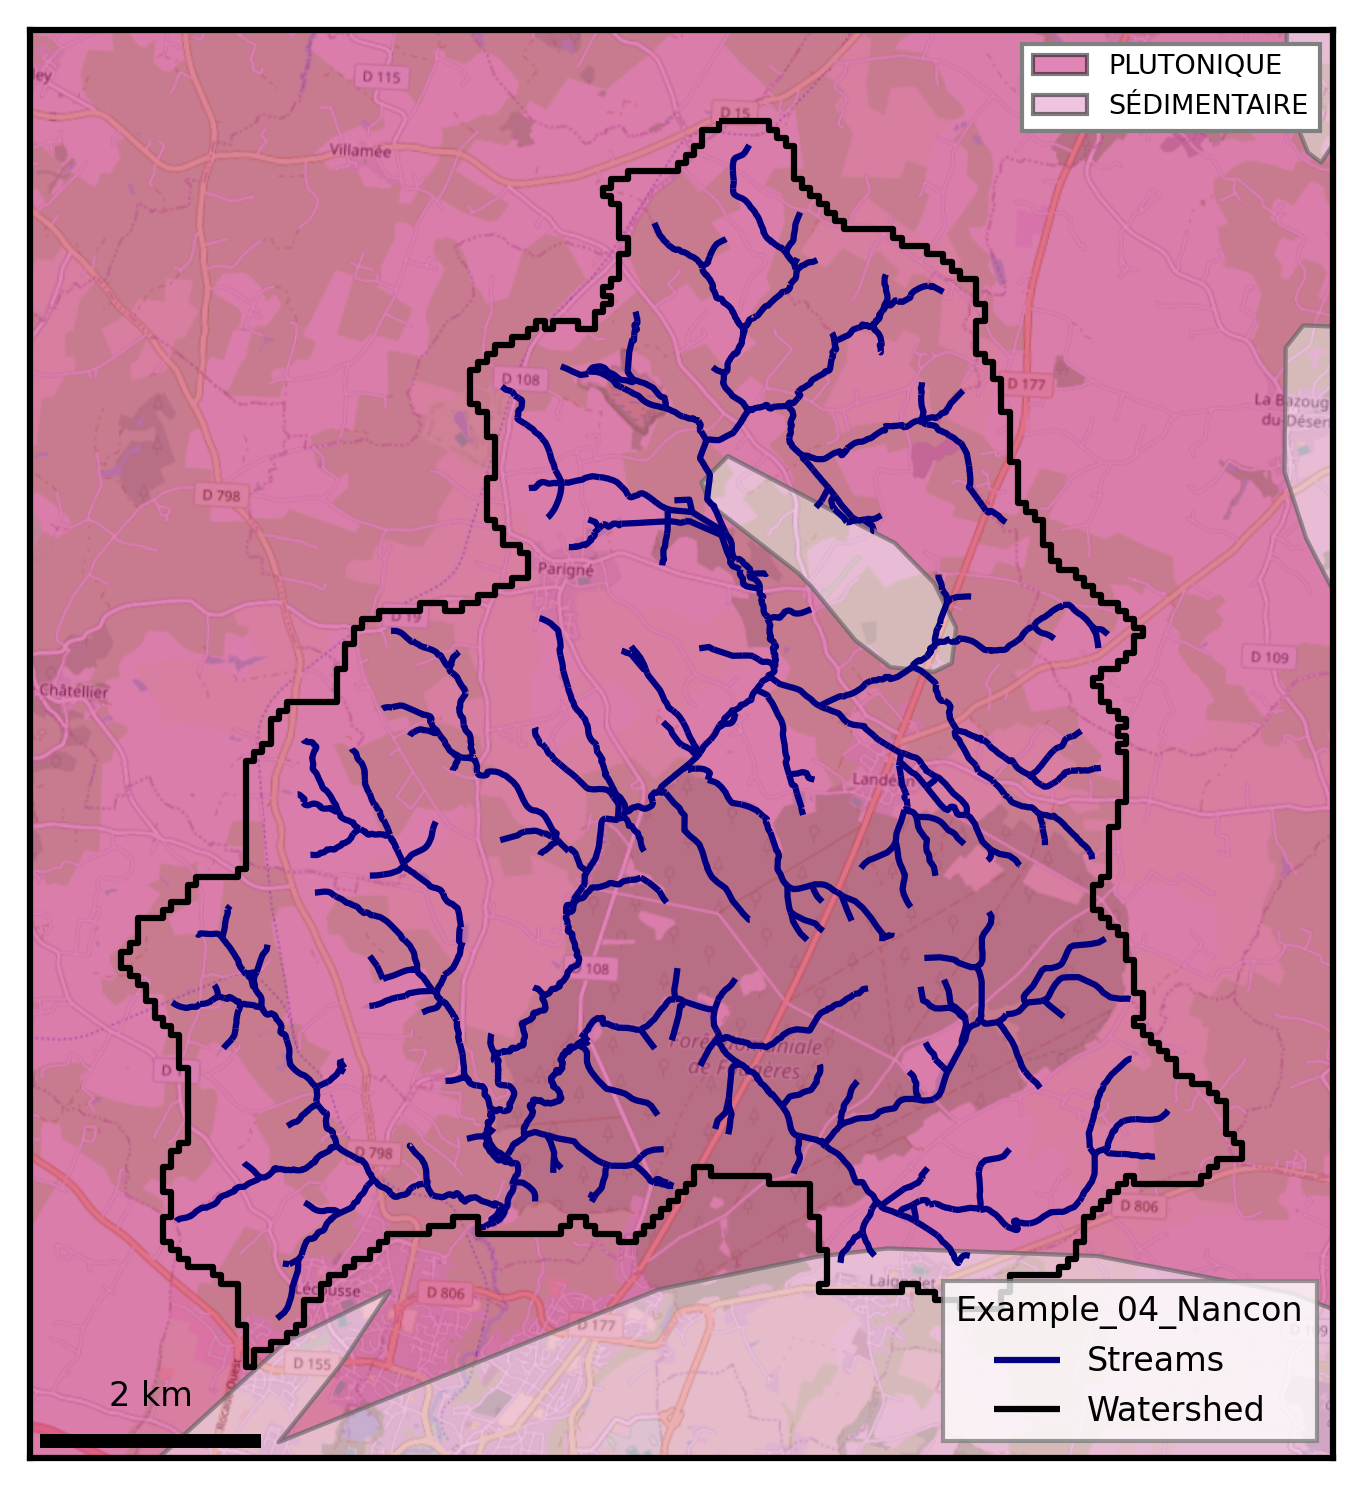

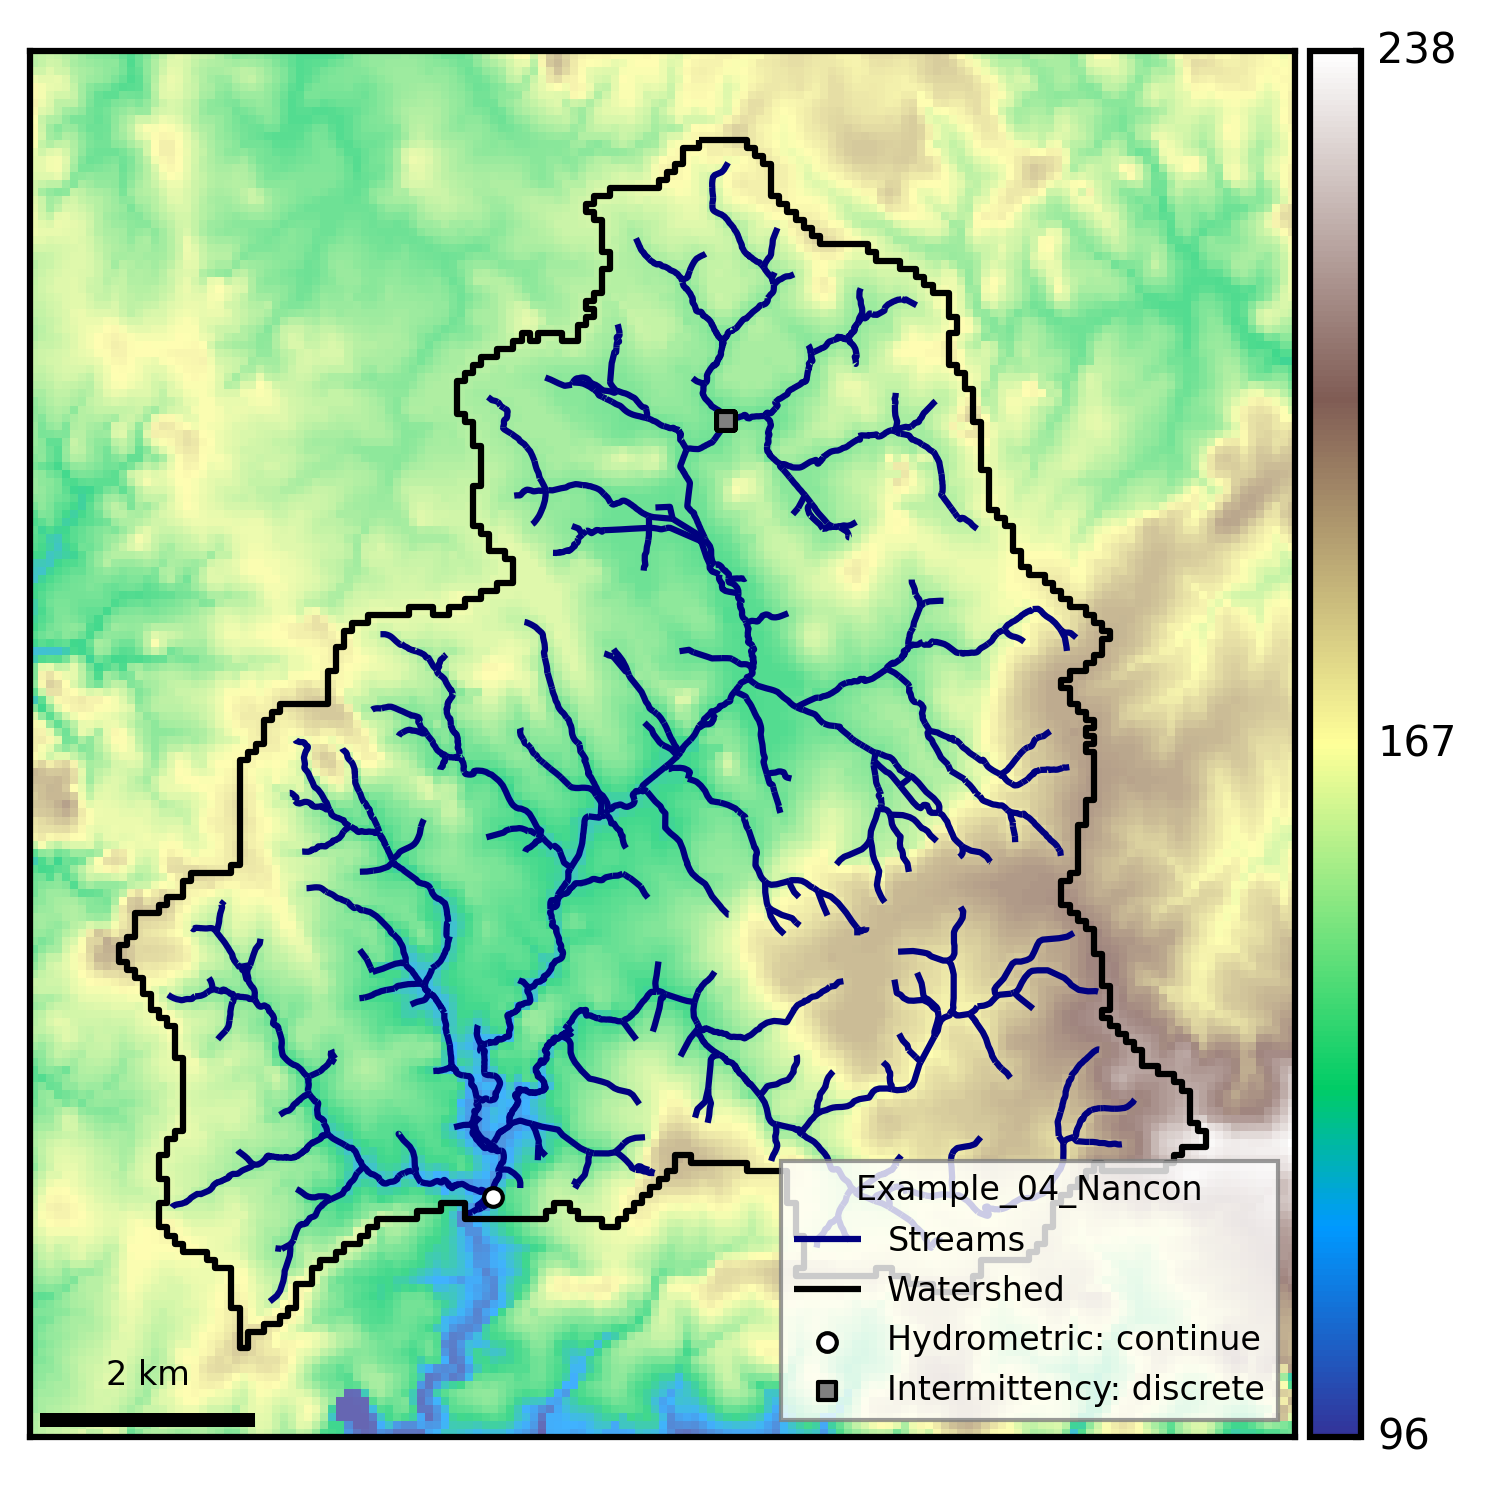

In [7]:

visualization_watershed.watershed_local(dem_path, BV)

# Clip specific data at the catchment scale
BV.add_geology(data_path, types_obs='GEO1M.shp', fields_obs='CODE_LEG')
BV.add_hydrography(data_path, types_obs=['regional stream network'])
BV.add_hydrometry(data_path, 'france hydrometric stations.shp')
BV.add_intermittency(data_path, 'regional onde stations.shp')
# BV.add_piezometry()

# Extract some subbasin from data available above
BV.add_subbasin(os.path.join(data_path, 'additional'), 150)

# General plot of the study site
visualization_watershed.watershed_geology(BV)
visualization_watershed.watershed_dem(BV)



Init climatic module to set model parameter
Extract climatic data from web
No additional .csv dataset need to be downloaded.

Clipping on watershed_box...
   RUNC_Q_SIM2_20000101_20091231.nc (1/2)
   DRAINC_Q_SIM2_20000101_20091231.nc (2/2)

Merging DRAINC_Q (recharge) files...
   DRAINC_Q_SIM2_20000101_20091231.nc

Merging RUNC_Q (runoff) files...
   RUNC_Q_SIM2_20000101_20091231.nc

Formatting results for HydroModPy model...
   recharge
      . refining period...
      . reprojecting...
      . simplify spatial dimensions...
      . resampling time...
   runoff
      . refining period...
      . reprojecting...
      . simplify spatial dimensions...
      . resampling time...


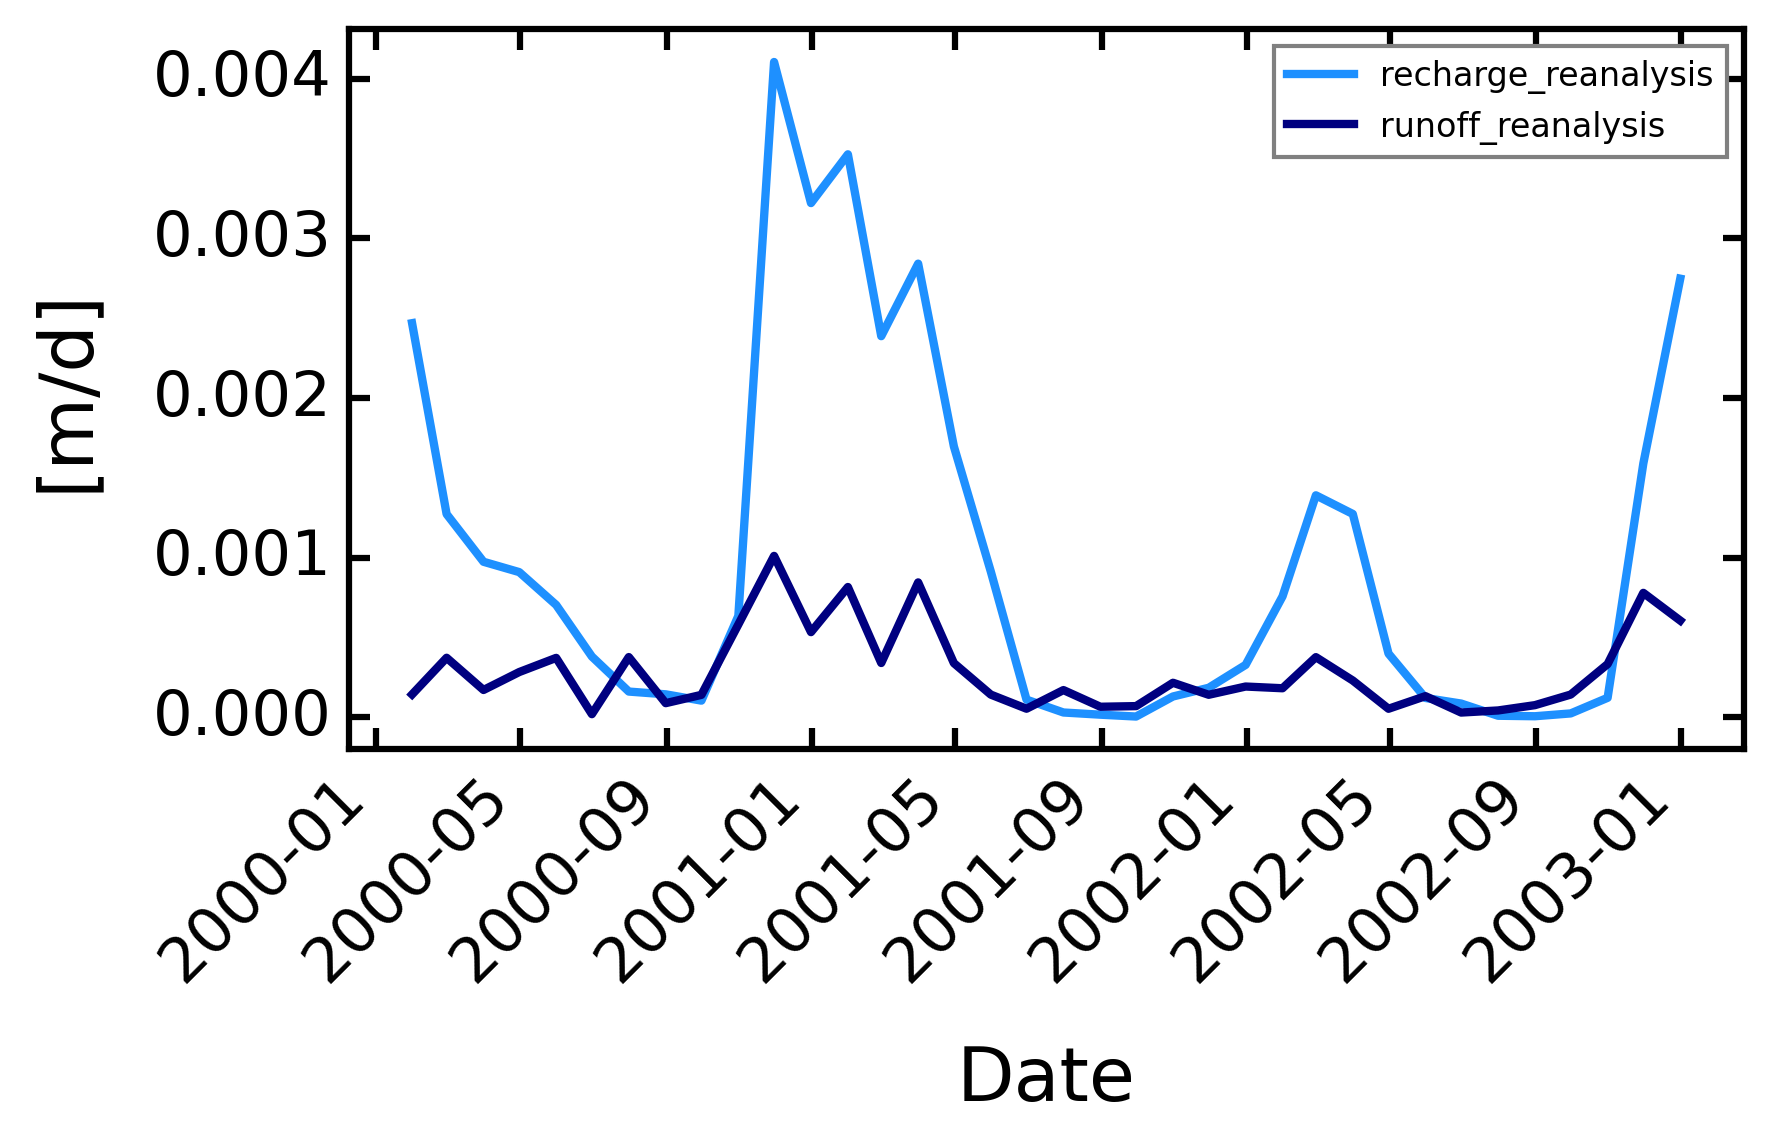

In [8]:

# Necessary to set model parameters
BV.add_climatic()

# clim_data_mode = 'local' # local climatic data
clim_data_mode = 'SIM2' # SIM2 online climatic data (https://meteo.data.gouv.fr/datasets/6569b27598256cc583c917a7)

if clim_data_mode == 'SIM2':
    BV.climatic.update_sim2_reanalysis(var_list=['recharge', 'runoff',
                                                ], 
                                            nc_data_path=os.path.join(
                                                stable_folder,
                                                'add_data',
                                                'climatic'),
                                            first_year=2000,
                                            last_year=2002,
                                            time_step='M',
                                            sim_state='transient',
                                            spatial_mean=True,
                                            geographic=BV.geographic,
                                            disk_clip='watershed')

    ### Units
    BV.climatic.update_recharge(BV.climatic.recharge / 1000, sim_state='transient') # from mm to m
    BV.climatic.update_runoff(BV.climatic.runoff / 1000, sim_state='transient') # from mm to m
    
    ### Format for plots
    if isinstance(BV.climatic.recharge, float):
        print(f"Time-space daily average value for recharge = {BV.climatic.recharge} m")
        print(f"Time-space daily average value for runoff = {BV.climatic.runoff} m")
    else:
        if isinstance(BV.climatic.recharge, xr.core.dataset.Dataset):
            R = BV.climatic.recharge.drop('spatial_ref').mean(dim = ['x', 'y']).to_pandas().iloc[:,0]
            r = BV.climatic.runoff.drop('spatial_ref').mean(dim = ['x', 'y']).to_pandas().iloc[:,0]
            # R = R.resample('M').sum()
            # r = r.resample('M').sum()
        elif isinstance(BV.climatic.recharge, pd.core.series.Series):  
            R = BV.climatic.recharge
            r = BV.climatic.runoff
        
elif clim_data_mode == 'local':
    x = pd.read_csv(data_path+'/'+'_climate_REANALYSIS.csv', sep=';', index_col=0)
    date_object = pd.to_datetime(x.index, format = "%d/%m/%Y")
    x.index = date_object
    x = x.sort_index()
    x = x.resample('M').mean()
    x = select_period(x, 2000, 2002)
    BV.climatic.update_recharge(x['REC_REA_historic'] / 1000, sim_state='transient') # from mm to m
    BV.climatic.update_runoff(x['RUN_REA_historic'] / 1000, sim_state='transient') # from mm to m
    R = BV.climatic.recharge
    r = BV.climatic.runoff
    
# Plots
fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(R, label='recharge_reanalysis', c='dodgerblue', lw=2)
ax.plot(r, label='runoff_reanalysis', c='navy', lw=2)
ax.set_xlabel('Date')
ax.set_ylabel('[m/d]')
plt.xticks(rotation=45, ha="right")
ax.legend()



In [9]:

# Frame settings
box = True # or False
sink_fill = False # or True
# sim_state = 'transient' # 'steady' or 'transient'
sim_state = 'transient' # 'steady' or 'transient'
plot_cross = False
dis_perlen = True

# Climatic settings
first_clim = 'first' # or 'first or value
freq_time = 'M'

# Hydraulic settings
nlay = 1
lay_decay = 1 # 1 for no decay
bottom = None # elevation in meters, None for constant auifer thickness, or 2D matrix
thick = 30 # if bottom is None, aquifer thickness
hk = 5e-5 * 3600 * 24 # m/day
cond_drain = None # or value of conductance

########## LOOP ##########
list_porosity = np.array([0.1, 5, 30]) / 100 # [-]

# Boundary settings
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL
split_temp = True

# Particle tracking settings
zone_partic = 'domain' # or watershed

# plt.plot(hyd_cond/R)

iD_set_simulations = 'explorSy_test1'



In [10]:

# Import modules
BV.add_settings()
BV.add_climatic()
BV.add_hydraulic()

# Frame settings
BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.settings.update_check_model(plot_cross=plot_cross)

# Climatic settings
recharge = R.copy()
BV.climatic.update_recharge(recharge, sim_state=sim_state)
BV.climatic.update_first_clim(first_clim)

# Hydraulic settings
BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_lay_decay(lay_decay) # 1
BV.hydraulic.update_bottom(bottom) # None
BV.hydraulic.update_thick(thick) # 30 / intervient pas si bottom != None
BV.hydraulic.update_hk(hk)
BV.hydraulic.update_cond_drain(cond_drain)

# Boundary settings
BV.settings.update_bc_sides(bc_left, bc_right)
BV.add_oceanic(sea_level)
BV.settings.update_dis_perlen(dis_perlen)

# Particle tracking settings
BV.settings.update_input_particles(zone_partic=BV.geographic.watershed_box_buff_dem) # or 'seepage_path'



Init settings module to set model parameter
Init climatic module to set model parameter
Init hydraulic module to set model parameter


In [11]:

list_model_name = []
list_success_modflow = []
list_model_modflow = []

for i, sy in enumerate(list_porosity[:]):
    BV.hydraulic.update_sy(sy)
    
    model_name = iD_set_simulations+'_'+str(i)+'_'+str(round(sy,3))
    BV.settings.update_model_name(model_name)
    print(model_name)
    
    model_modflow = BV.preprocessing_modflow(for_calib=False)
    success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)
    
    list_model_name.append(model_name)
    list_success_modflow.append(success_modflow)
    list_model_modflow.append(model_modflow)

dictio = {}
dictio['list_model_name'] = list_model_name
dictio['list_success_modflow'] = list_success_modflow
dictio['list_model_modflow'] = list_model_modflow
h5file = os.path.join(simulations_folder, 'results_listing_'+iD_set_simulations)
    
dd.io.save(h5file, dictio)



explorSy_test1_0_0.001
Check model grid: all cells satisfy the water flow connectivity condition
FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: explorSy_test1_0_0.001.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/01/09 12:02:06

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     2    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     3    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     4    Time s

In [12]:

iD_set_simulations = 'explorSy_test1'

h5file = os.path.join(simulations_folder, 'results_listing_'+iD_set_simulations)
d = dd.io.load(h5file)
list_model_name = d['list_model_name'][:]
list_success_modflow = d['list_success_modflow'][:]
list_model_modflow = d['list_model_modflow'][:]



In [13]:

# from importlib import reload
# reload(watershed_root)
# reload(modflow)

for model_name, success_modflow, model_modflow in zip(list_model_name,
                                                      list_success_modflow,
                                                      list_model_modflow):
    if success_modflow == True:
        BV.postprocessing_modflow(model_modflow,
                                  watertable_elevation = True,
                                  watertable_depth= True, 
                                  seepage_areas = True,
                                  outflow_drain = True,
                                  groundwater_flux = True,
                                  groundwater_storage = True,
                                  accumulation_flux = True,
                                  persistency_index=True,
                                  intermittency_monthly=True,
                                  intermittency_daily=False,
                                  export_all_tif = False)

        timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                          model_modpath=None,
                                                          datetime_format=True, 
                                                          subbasin_results=True,
                                                          intermittency_monthly=True) # or None
        
        netcdf_results = BV.postprocessing_netcdf(model_modflow,
                                                  datetime_format=True)



 Post-processing:  Stress period:    1  /  36
 Post-processing:  Stress period:    2  /  36
 Post-processing:  Stress period:    3  /  36
 Post-processing:  Stress period:    4  /  36
 Post-processing:  Stress period:    5  /  36
 Post-processing:  Stress period:    6  /  36
 Post-processing:  Stress period:    7  /  36
 Post-processing:  Stress period:    8  /  36
 Post-processing:  Stress period:    9  /  36
 Post-processing:  Stress period:    10  /  36
 Post-processing:  Stress period:    11  /  36
 Post-processing:  Stress period:    12  /  36
 Post-processing:  Stress period:    13  /  36
 Post-processing:  Stress period:    14  /  36
 Post-processing:  Stress period:    15  /  36
 Post-processing:  Stress period:    16  /  36
 Post-processing:  Stress period:    17  /  36
 Post-processing:  Stress period:    18  /  36
 Post-processing:  Stress period:    19  /  36
 Post-processing:  Stress period:    20  /  36
 Post-processing:  Stress period:    21  /  36
 Post-processing:  Str

32
2002-09
10
2000-11
33
2002-10
0
2000-01
33
2002-10
0
2000-01


<bound method Figure.tight_layout of <Figure size 1500x3000 with 3 Axes>>

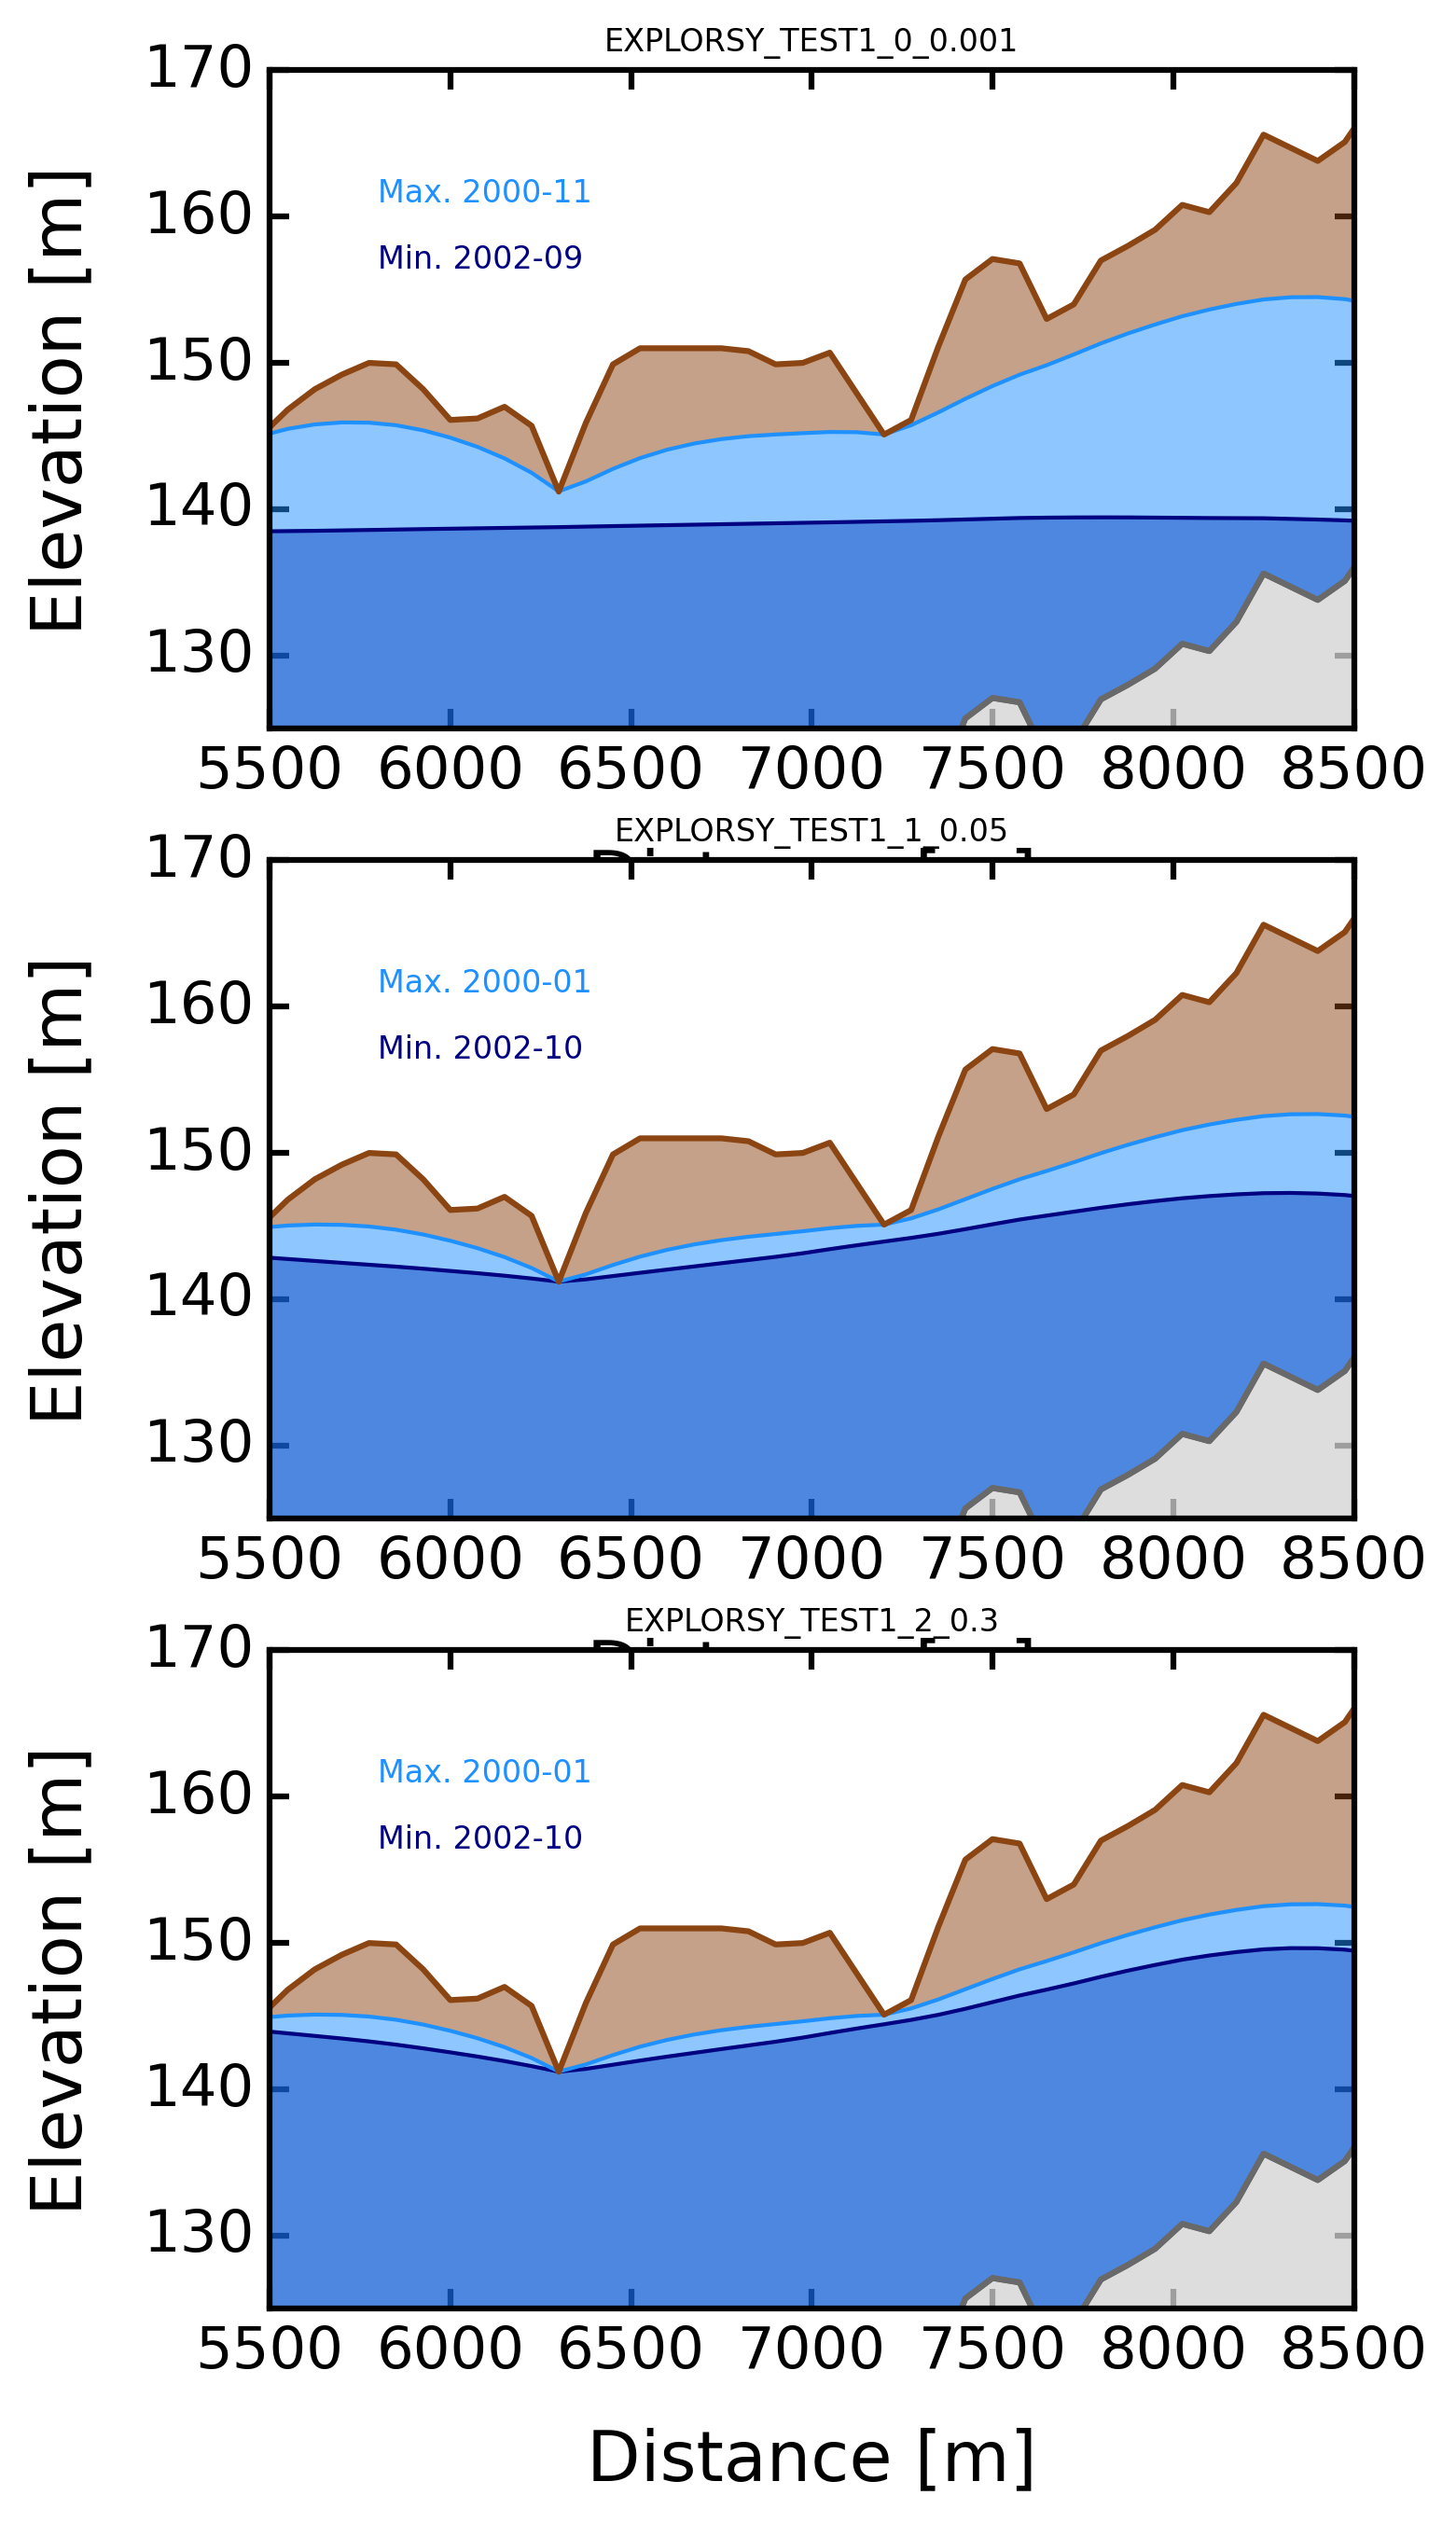

In [14]:

dates = pd.date_range(start='01/01/2000', end='31/12/2002', freq='M')
    
stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')

simul_list = sorted(glob.glob(os.path.join(simulations_folder, iD_set_simulations+'*')),
                    key=os.path.getmtime)

fig, axs = plt.subplots(3, 1, figsize=(5,10), dpi=300)
axs = axs.ravel()

for i, simul in enumerate(simul_list[:]):
        
    model_name = os.path.split(simul)[-1]
    
    ax = axs[i]

    Smod_path = os.path.join(simul, r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)
    Smod = Smod.reset_index()
    argmin = Smod['total_areas'].argmin()
    argmax = Smod['total_areas'].argmax()
    
    mask = imageio.imread(os.path.join(stable_folder, 'geographic', 'watershed_dem.tif'))
        
    
    watertable_elevation = np.load(os.path.join(simulations_folder, 
                                                model_name, '_postprocess',
                                                'watertable_elevation'+'.npy'),
                                   allow_pickle=True).item()
    
    min_wt = dict()
    
    cp = 0

    for i, key in enumerate([argmin, argmax]):
        print(key)

        dem_data = imageio.imread(BV.geographic.watershed_dem)
        wt_data = watertable_elevation[key]
        # river_data = imageio.imread(os.path.join(stable_folder, 'hydrography',
        #                                           'regional stream network.tif'))
    
        xvalues = np.linspace(-1,1,dem_data.shape[1])
        yvalues = np.linspace(-1,1,dem_data.shape[0])
        xx, yy = np.meshgrid(xvalues,yvalues)
        
        cur_x = dem_data.shape[1] /2
        cur_y = dem_data.shape[0] /2 # 39
        cur_y = 39
        
        dem_max = dem_data.max()
        dem_prof = dem_data.astype(float)
        dem_prof[dem_prof<0] = np.nan
        wt_prof = wt_data.astype(float)
        wt_prof[wt_prof<0] = np.nan
        
        dem_h_plot = dem_prof[int(cur_y),:]
        dem_h_plot[dem_h_plot == 0] = np.nan
        wt_h_plot = wt_prof[int(cur_y),:]
        wt_h_plot[wt_h_plot == 0] = np.nan
                    
        dem_max = dem_data.max()
        dem_prof = dem_data.astype(float)
        dem_prof[dem_prof<0] = np.nan
        dem_plot = np.ma.masked_array(dem_data, mask=(dem_data<0))
        
        wt_prof = wt_data.astype(float)
        wt_prof[wt_prof<0] = np.nan
        
        cp+=1

        if i == 0:
            wt_h_fill = ax.fill_between(np.arange(xx.shape[1])*75, dem_h_plot-30, wt_h_plot,
                                            color='navy', alpha=0.5, lw=0)
            w_prof = ax.plot(np.arange(xx.shape[1])*75, wt_h_plot, color='navy', lw=1)
        if i == 1:
            wt_h_fill = ax.fill_between(np.arange(xx.shape[1])*75, dem_h_plot-30, wt_h_plot,
                                            color='dodgerblue', alpha=0.5, lw=0)
            w_prof = ax.plot(np.arange(xx.shape[1])*75, wt_h_plot, color='dodgerblue', lw=1)
            wt_h_fill = ax.fill_between(np.arange(xx.shape[1])*75, wt_h_plot, dem_h_plot,
                                            color='saddlebrown', alpha=0.5, lw=0)
            d_prof = ax.plot(np.arange(xx.shape[1])*75, dem_h_plot, 'saddlebrown', lw=1.5)
        ax.fill_between(np.arange(xx.shape[1])*75, 0, dem_h_plot-30,
                                        color='lightgrey', alpha=0.5, lw=0)
        ax.plot(np.arange(xx.shape[1])*75, dem_h_plot-30, color='dimgray', lw=1.5)
        ax.set_xlim(5500, 8500)
        ax.set_ylim(125, 170)
        ax.set_yticks([130,140,150,160,170])
        ax.set_xlabel('Distance [m]')
        ax.set_ylabel('Elevation [m]')
        
        ax.set_title(model_name.upper(), fontsize=8)
        if i == 1:
            ax.text(0.1, 0.8, 'Max. '+str(dates[key])[:7],
                    transform=ax.transAxes, color='dodgerblue')
        if i == 0:
            ax.text(0.1, 0.7, 'Min. '+str(dates[key])[:7],
                    transform=ax.transAxes, color='navy')
        print((str(dates[key])[:7]))
            
fig.tight_layout
        
# fig.savefig(os.path.join(simulations_folder, '_figures',
#             'CROSS_'+iD_set_simulations+'.png'),
#             bbox_inches='tight')
    


0/3
1/3
2/3
0/3
1/3
2/3
0/3
1/3
2/3


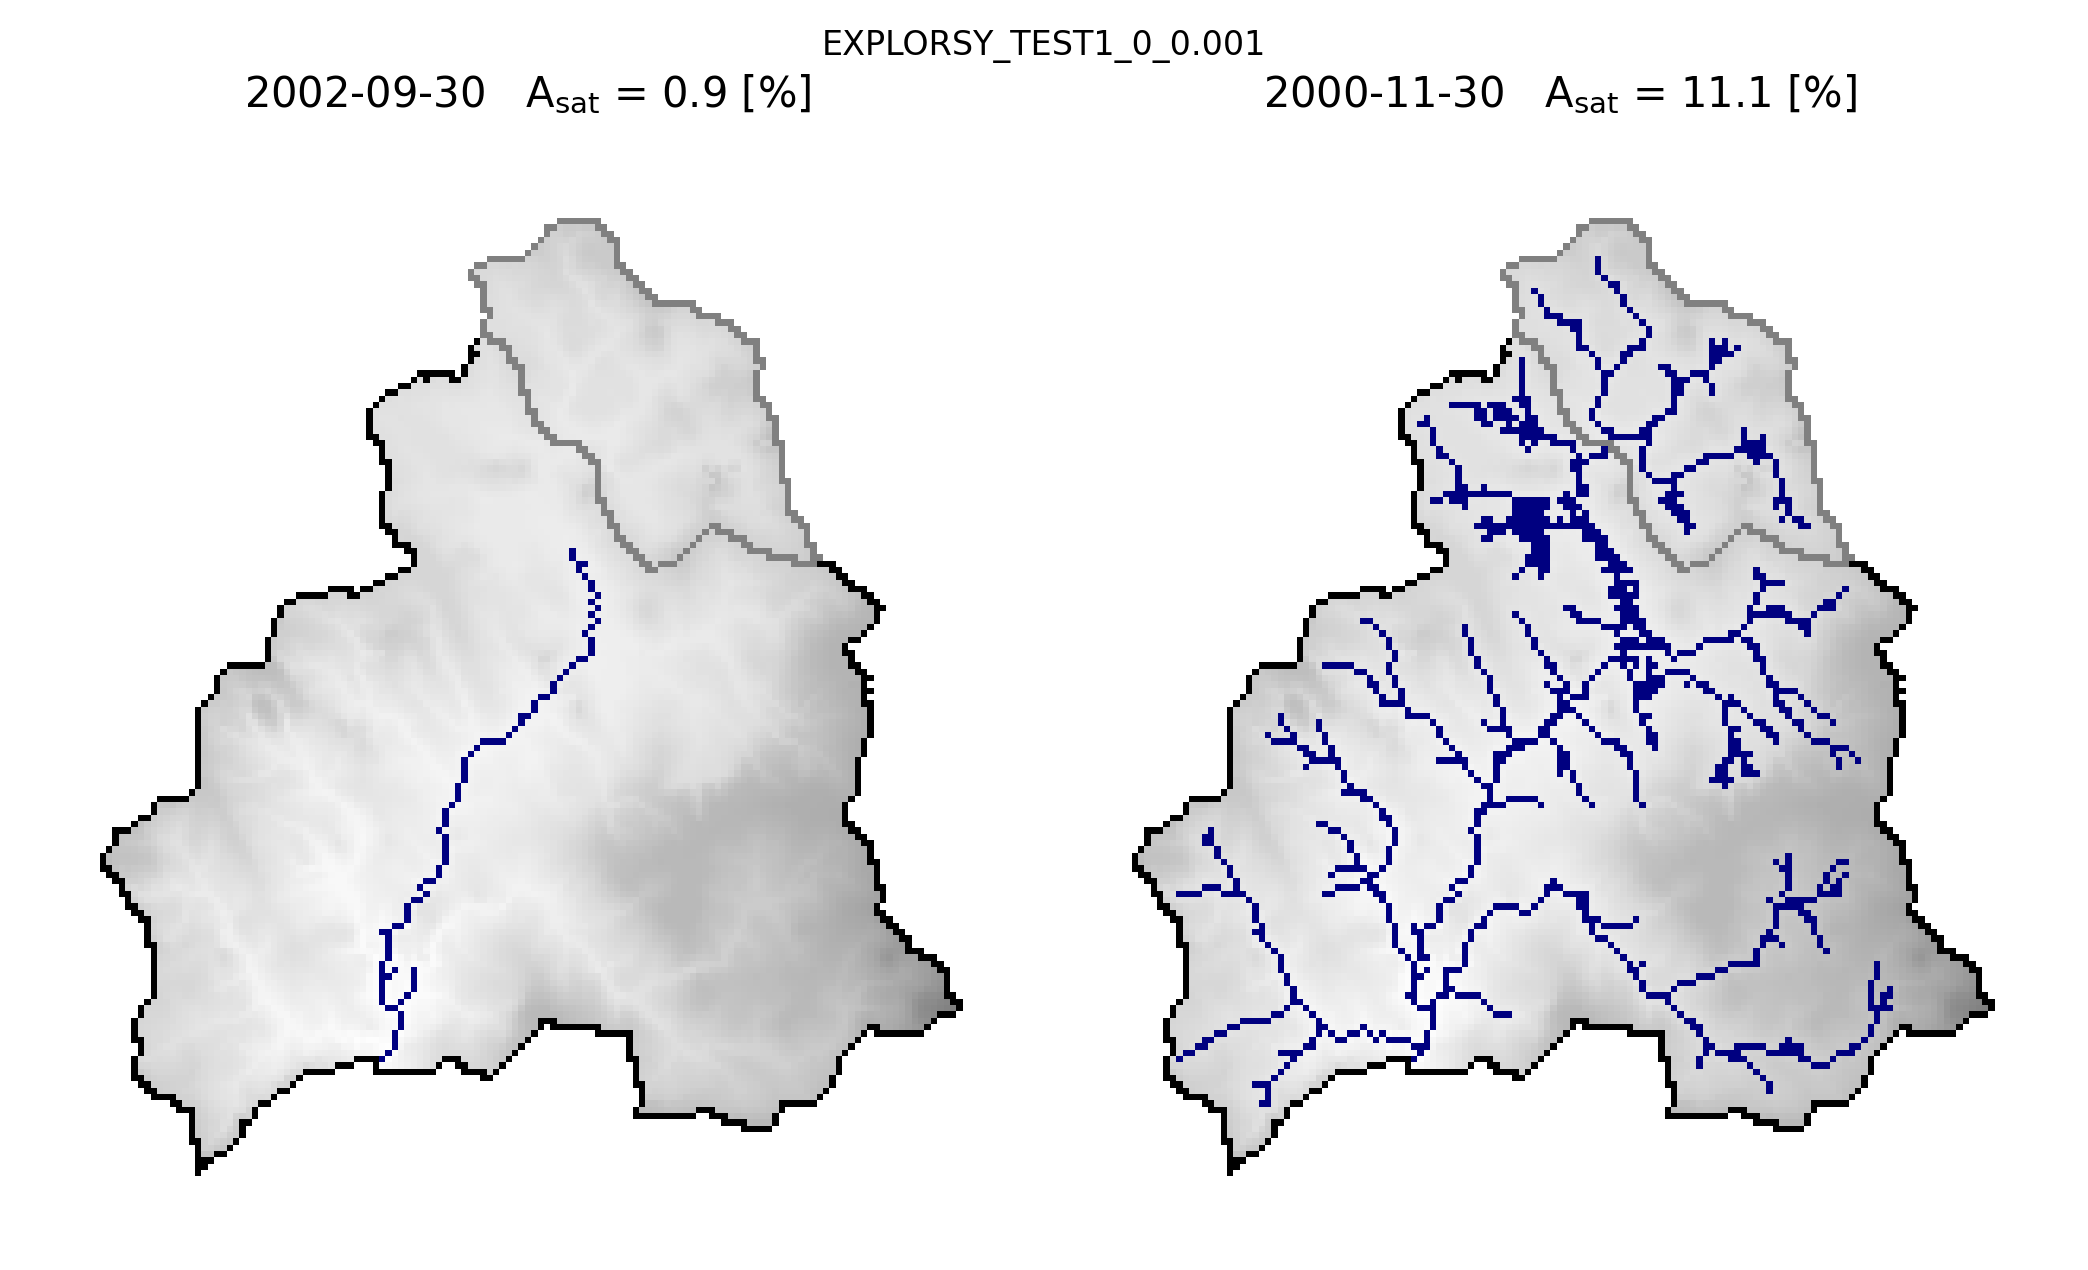

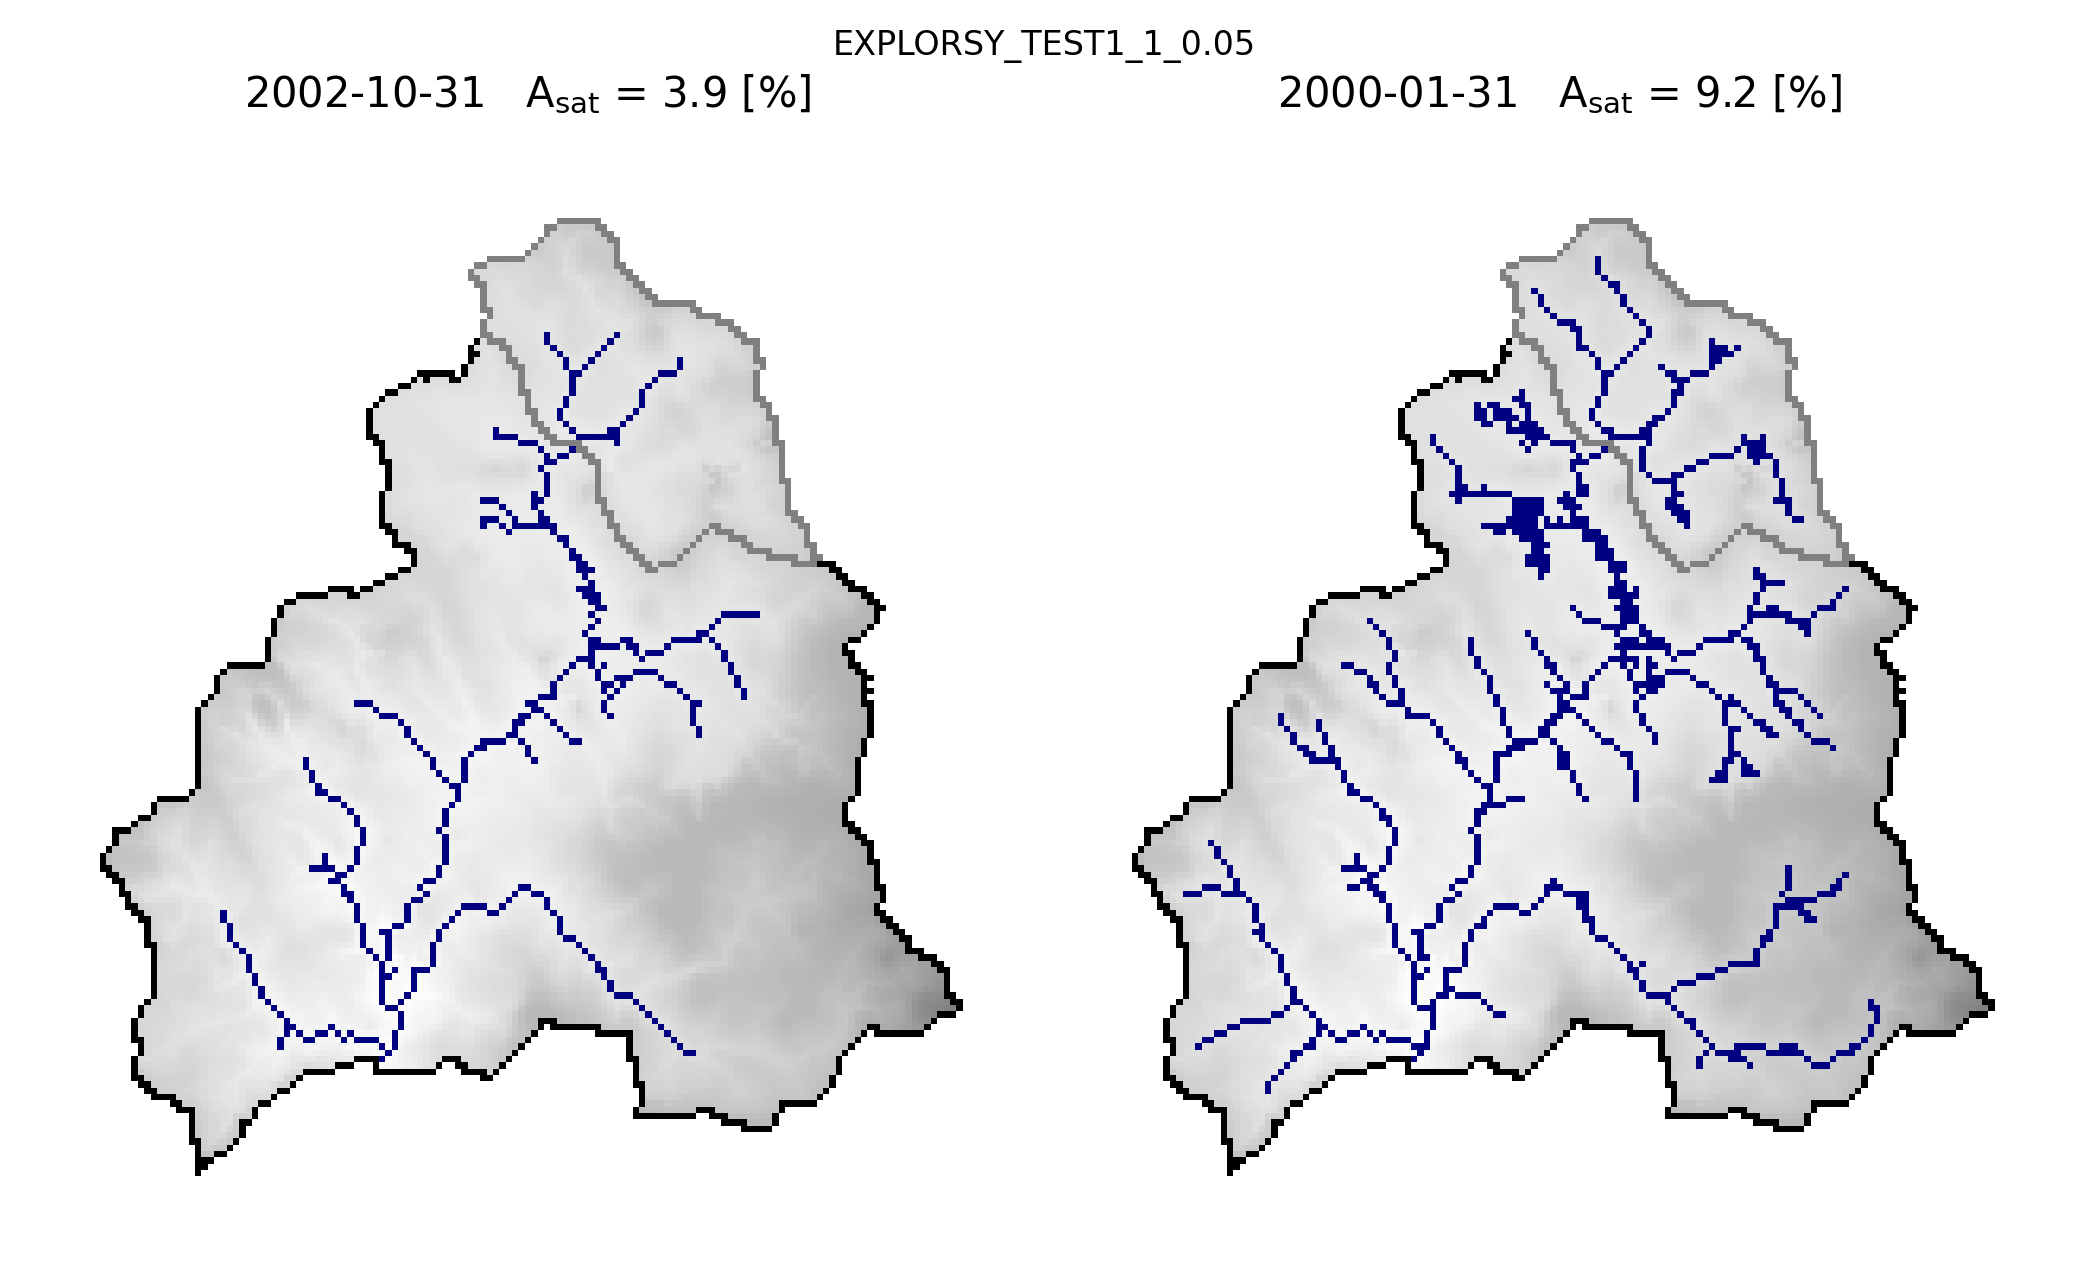

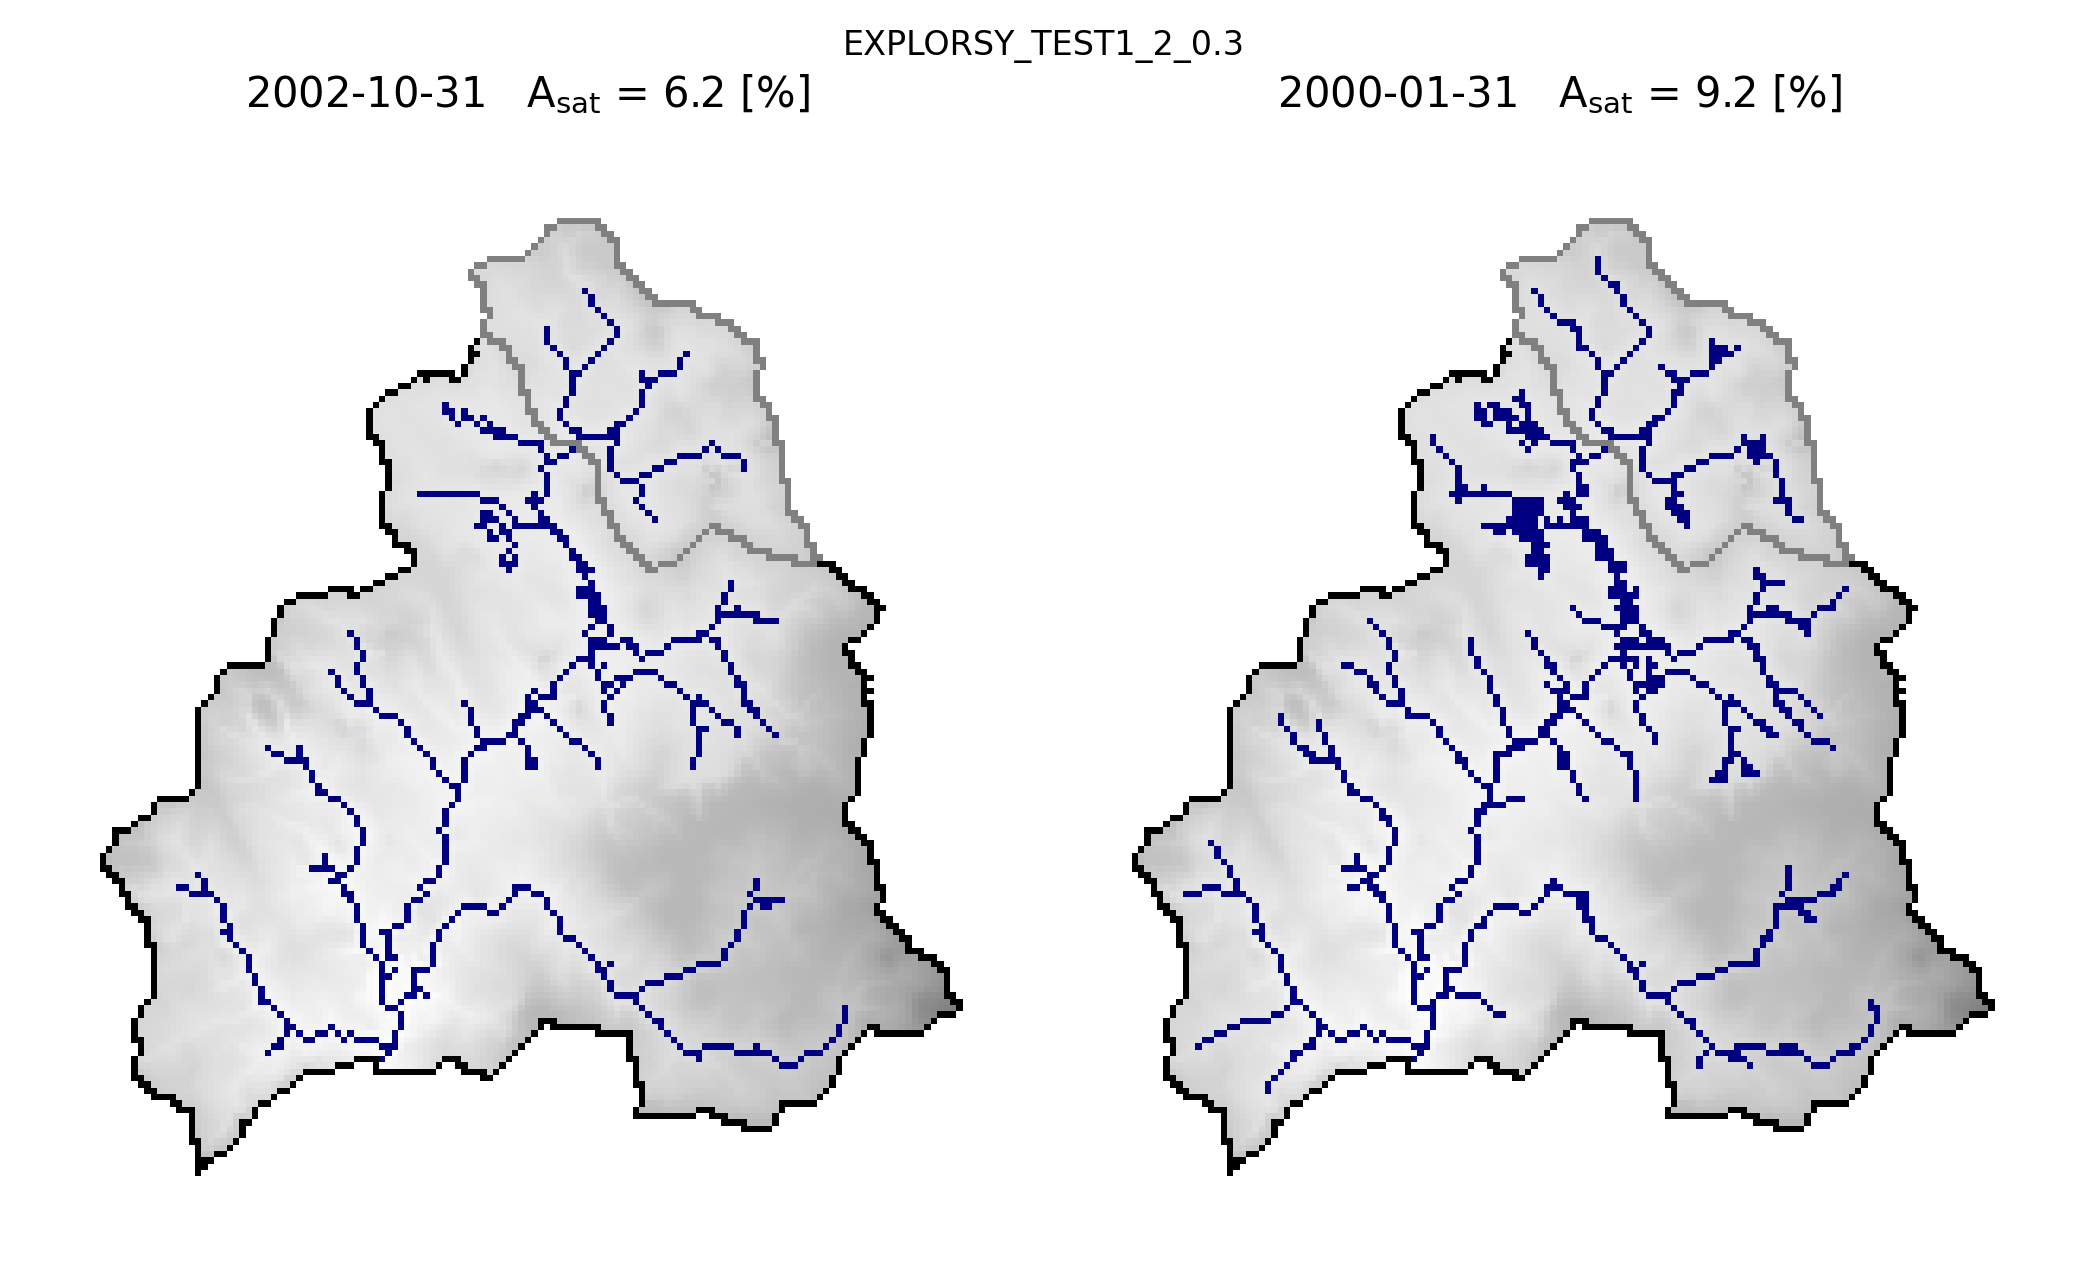

In [15]:

dates = pd.date_range(start='01/01/2000', end='31/12/2002', freq='M')
    
stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')

line = imageio.imread(os.path.join(stable_folder, 'geographic', 'watershed_contour.tif'))
line = np.ma.masked_where(line <= 0, line)

mask = imageio.imread(os.path.join(stable_folder, 'geographic', 'watershed_dem.tif'))

simul_list = sorted(glob.glob(os.path.join(simulations_folder, iD_set_simulations+'*')),
                   key=os.path.getmtime)
        
for simul in simul_list[:]:
    
    model_name = os.path.split(simul)[-1]
        
    Smod_path = os.path.join(simul, r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)
        
    min_area = Smod['total_areas'].min()
    min_idx = np.argmin(Smod['total_areas'])
    max_area = Smod['total_areas'].max()
    max_idx = np.argmax(Smod['total_areas'])
    max_year = Smod['total_areas'].index[max_idx]
    
    acc_npy = np.load(os.path.join(simul, '_postprocess', 'accumulation_flux.npy'), allow_pickle=True).item()
    inf = 0
    sup = 12
    compt = 0
    step = int(round(len(acc_npy)/12))
    
    for i in range(step):
        print(str(i)+'/'+str(step))
        interv = list(acc_npy.items())[inf:sup]
        for key in range(len(interv)):
            interv[key] = np.ma.masked_array(interv[key][1], mask=(mask<0))

        zero = acc_npy[0] * 0
        for j in range(len(interv)):
            tempo = interv[j].copy()
            tempo[tempo>0] = 1
            zero = zero + tempo
        days_flux = zero.copy()
        days_flux = np.ma.masked_array(days_flux, mask=(mask<0))
        days_flux = np.ma.masked_array(days_flux, mask=(days_flux<=0))
    
    fig, axs = plt.subplots(1,2, figsize=(7,6))
    axs = axs = axs.ravel()
    
    for k, j in enumerate([min_idx, max_idx]):
            
        ax = axs[k]
    
        year = Smod['total_areas'].index[j]
        val = Smod.iloc[j]['total_areas']

        days_flux = acc_npy[j]
        
        ax.set_title(str(year)[0:10] + '   ' + '$A_{sat}$ = ' + str(val.round(1)) + ' [%]',
                     pad=10, fontsize=10)
        ax.imshow(np.ma.masked_where(mask<0, mask), cmap='Greys', alpha=0.5, zorder=0)
        ax.imshow(np.ma.masked_where((days_flux<=0) | (mask <0),
                                     days_flux), 
                  cmap = mpl.colors.ListedColormap(['navy'])) # dodgerblue
        ax.imshow(line, cmap=mpl.colors.ListedColormap('k'))
        
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.axis('off')
            
        try:
            path_sub = os.path.join(glob.glob(
                os.path.join(stable_folder, 'subbasin','intermittency*'))[0],
                'watershed_contour.shp')
            wbt.vector_lines_to_raster(path_sub,
                                       os.path.join(glob.glob(
                                           os.path.join(stable_folder,
                                                        'subbasin',
                                                        'intermittency*'))[0],
                                           'watershed_contour.tif'),
                                       base = os.path.join(stable_folder,
                                                           'geographic',
                                                           'watershed_dem.tif'))
            line_sub = imageio.imread(os.path.join(glob.glob(
                os.path.join(stable_folder, 'subbasin', 'intermittency*'))[0],
                'watershed_contour.tif'))
            line_sub = np.ma.masked_where(line_sub <= 0, line_sub)
            ax.imshow(line_sub, cmap=mpl.colors.ListedColormap('grey'))
        except:
            pass
        
    fig.suptitle(model_name.upper(), y=0.85, fontsize=8)
    
    fig.tight_layout()
                
    # fig.savefig(os.path.join(simulations_folder, '_figures',
    #             'MAPminmax_'+model_name+'.png'),
    #             bbox_inches='tight')



<bound method Figure.tight_layout of <Figure size 2100x1800 with 6 Axes>>

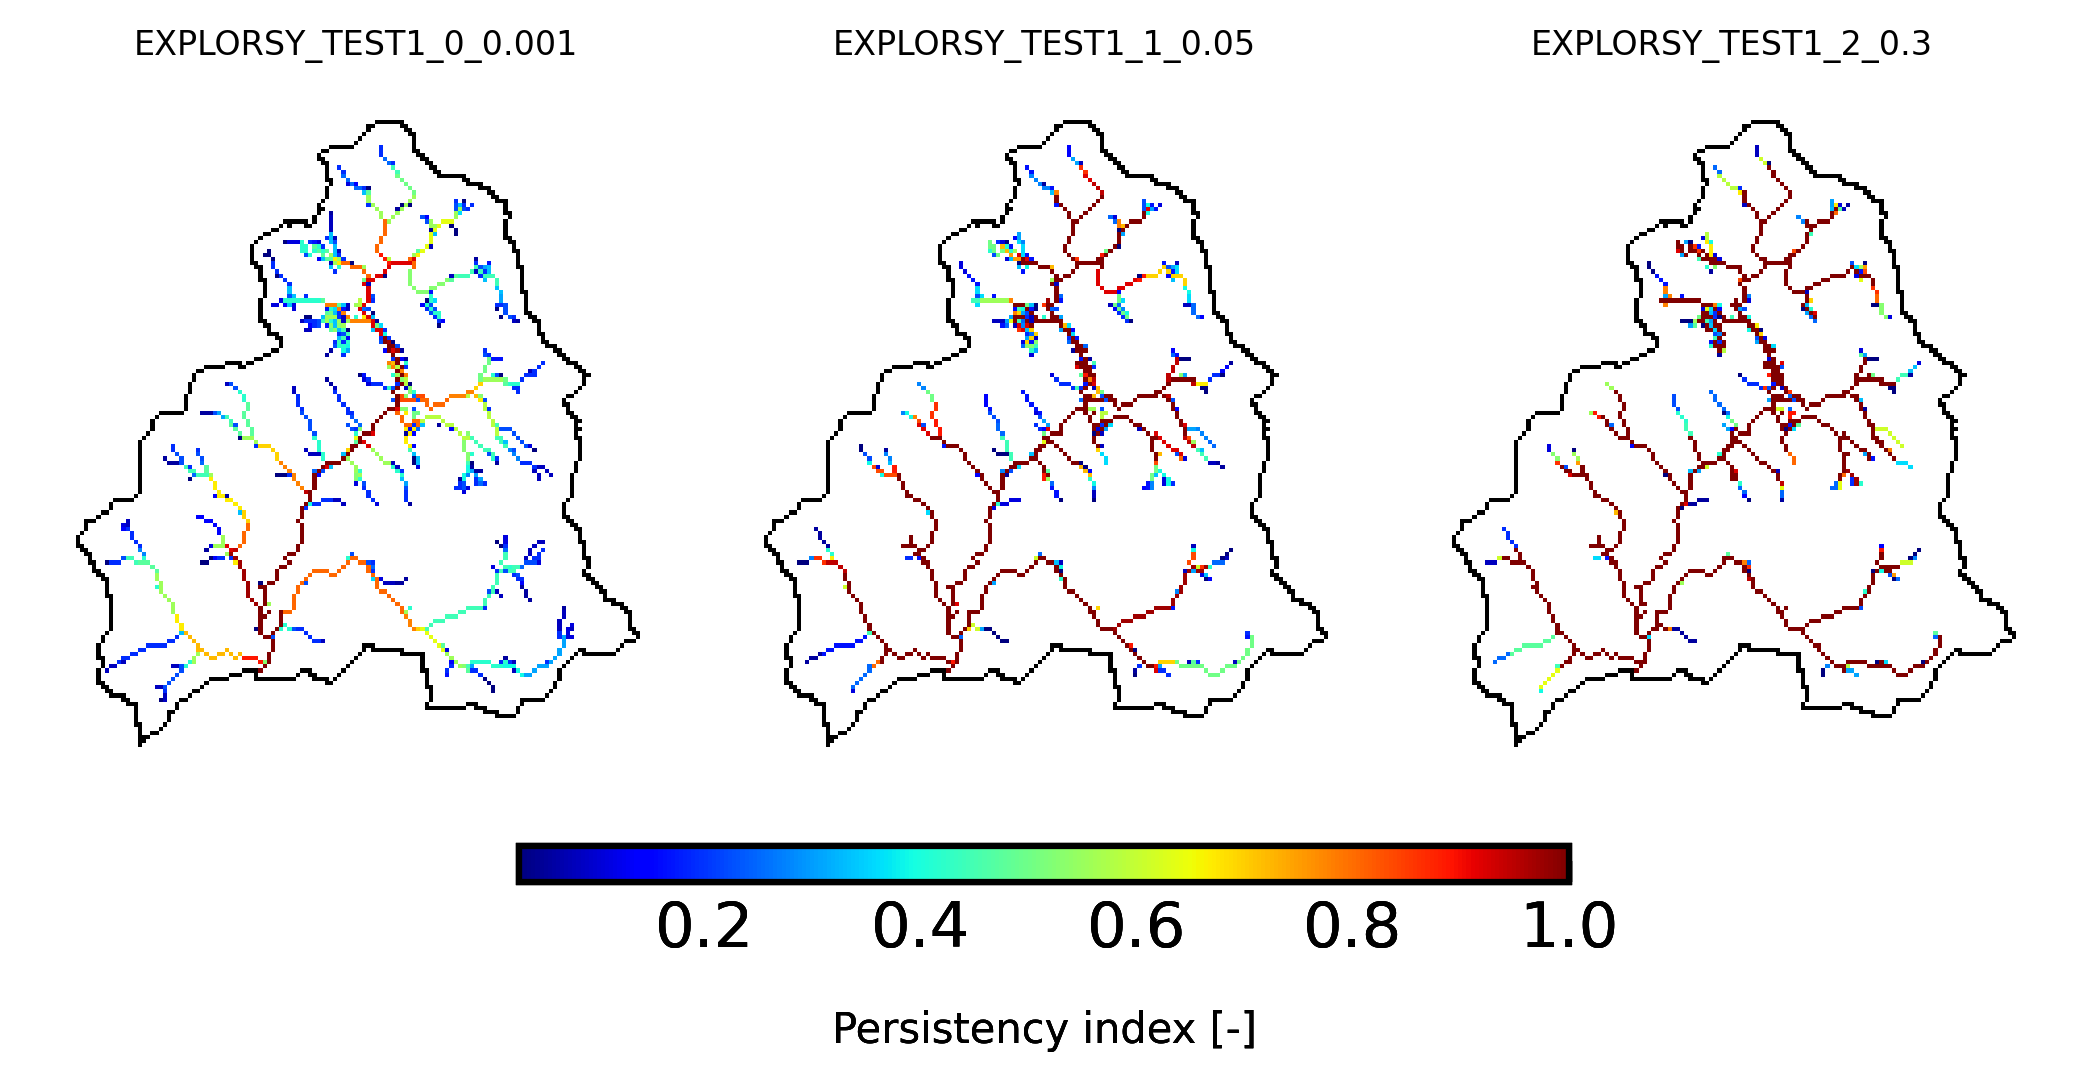

In [16]:

simul_list = sorted(glob.glob(os.path.join(simulations_folder, 
                                           iD_set_simulations+'*')),
                   key=os.path.getmtime)

line = imageio.imread(os.path.join(stable_folder,
                                   'geographic',
                                   'watershed_contour.tif'))
line = np.ma.masked_where(line <= 0, line)

mask = imageio.imread(os.path.join(stable_folder,
                                   'geographic',
                                   'watershed_dem.tif'))

fig, axs = plt.subplots(1, 3, figsize=(7,6))
axs = axs = axs.ravel()

for i, simul in enumerate(simul_list[:]):
        
    model_name = os.path.split(simul)[-1]

    ax = axs[i]
        
    pi = imageio.imread(os.path.join(simul, r'_postprocess/_rasters',
                                     'persistency_index_t(-).tif'))
    pi = np.ma.masked_where(pi==-9999, pi)
    pi = np.ma.masked_where(mask==-99999, pi)
    
    im = ax.imshow(pi, cmap='jet')
    
    ax.imshow(line, mpl.colors.ListedColormap(['k']),
                  vmin=0, vmax=1)
    
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.axis('off')
    
    ax.set_title(model_name.upper(), fontsize=8)
    
    # fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.25, 0.25, 0.5, 0.02])
    cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", pad=0.2)
    cb.set_label('Persistency index [-]', fontsize=10)  # cax == cb.ax
        
    fig.tight_layout()

fig.tight_layout
        
# fig.savefig(os.path.join(simulations_folder, '_figures',
#             'PI'+iD_set_simulations+'.png'),
#             bbox_inches='tight')
    


EXPLORSY_TEST1_0_0.001
0.61
-0.1
47.53
0.48
EXPLORSY_TEST1_1_0.05
0.88
0.89
36.55
0.88
EXPLORSY_TEST1_2_0.3
0.48
0.15
35.24
0.5


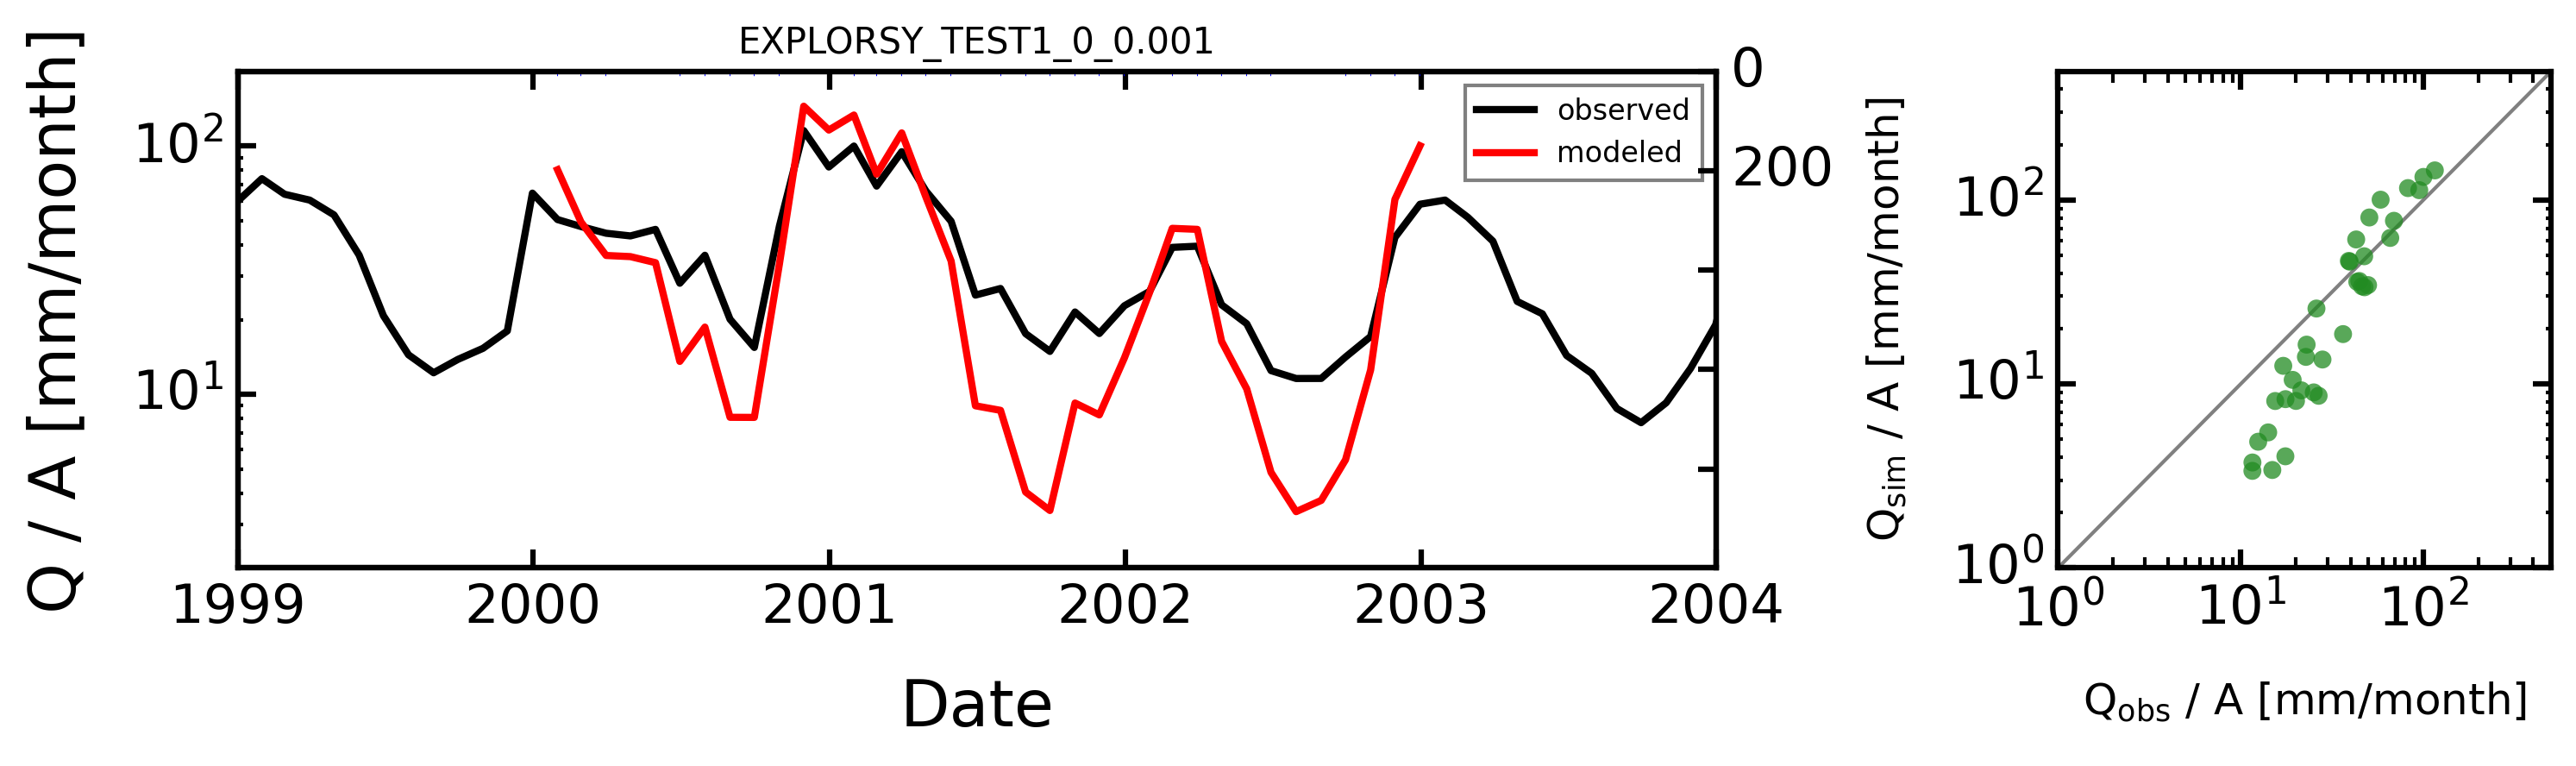

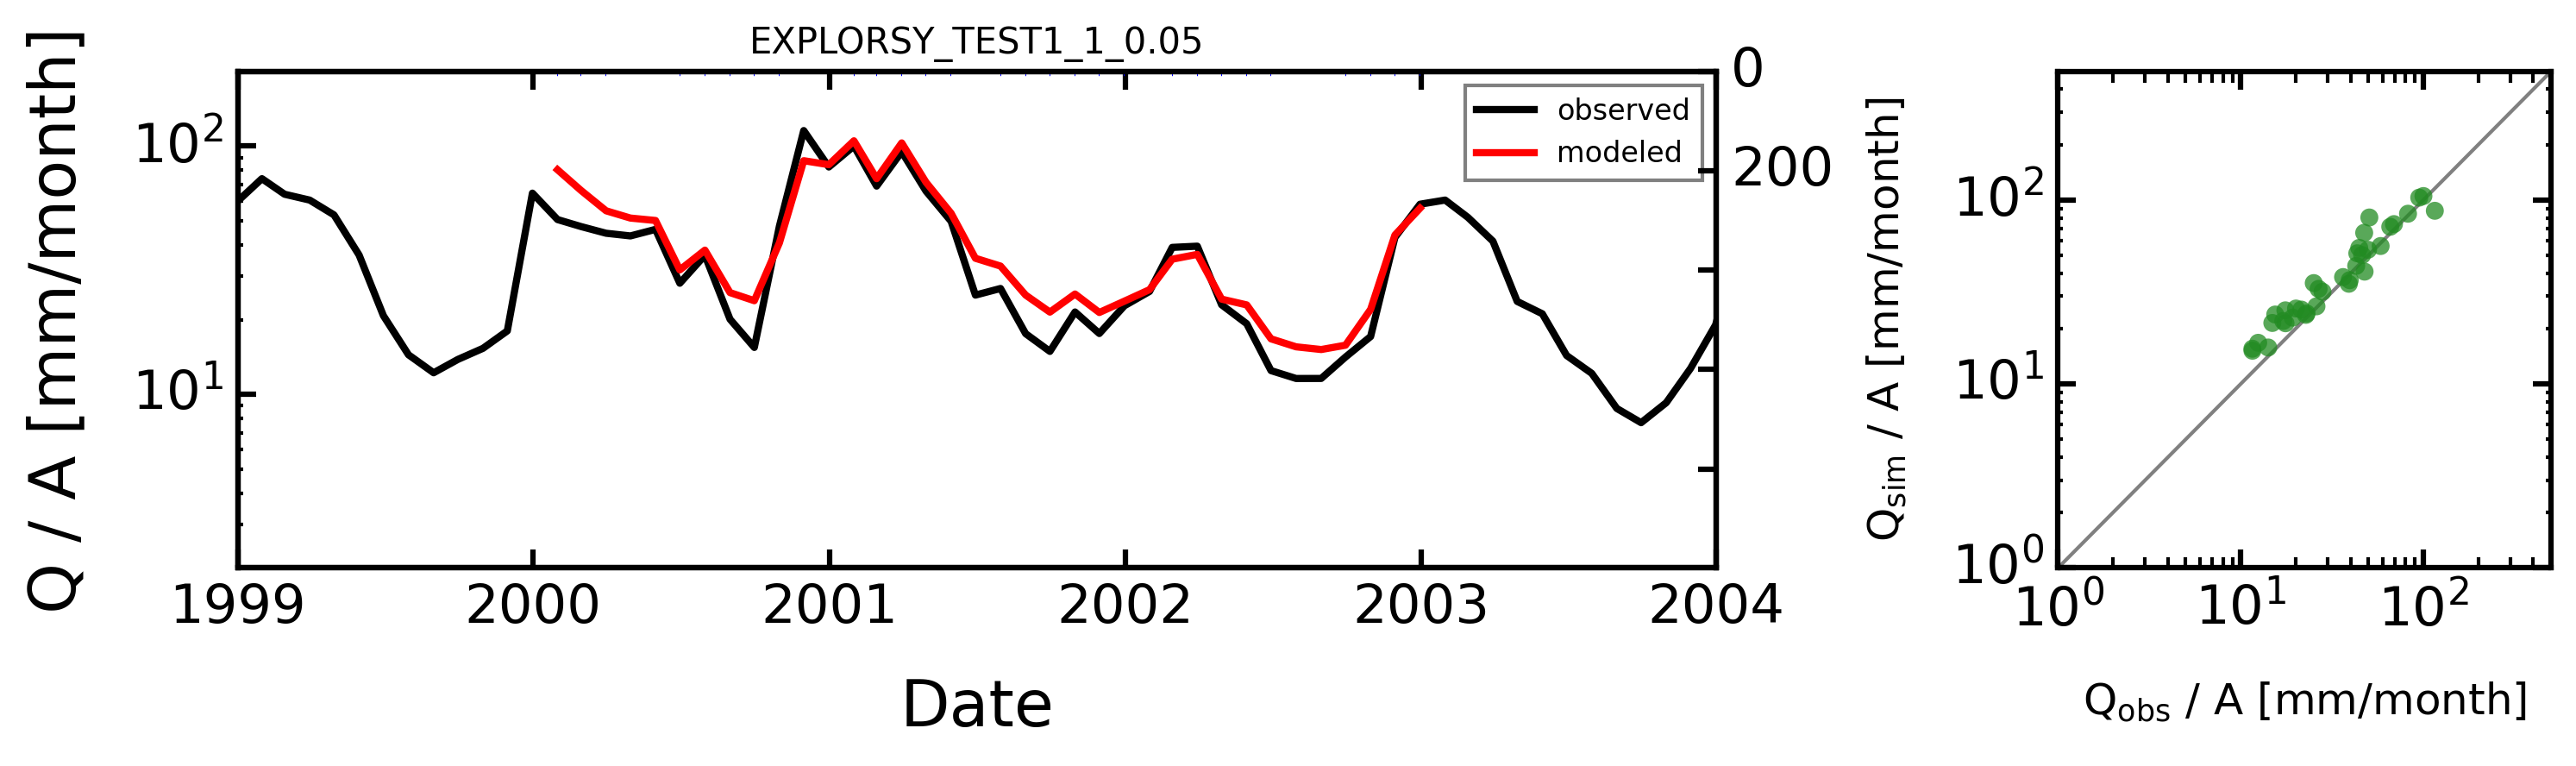

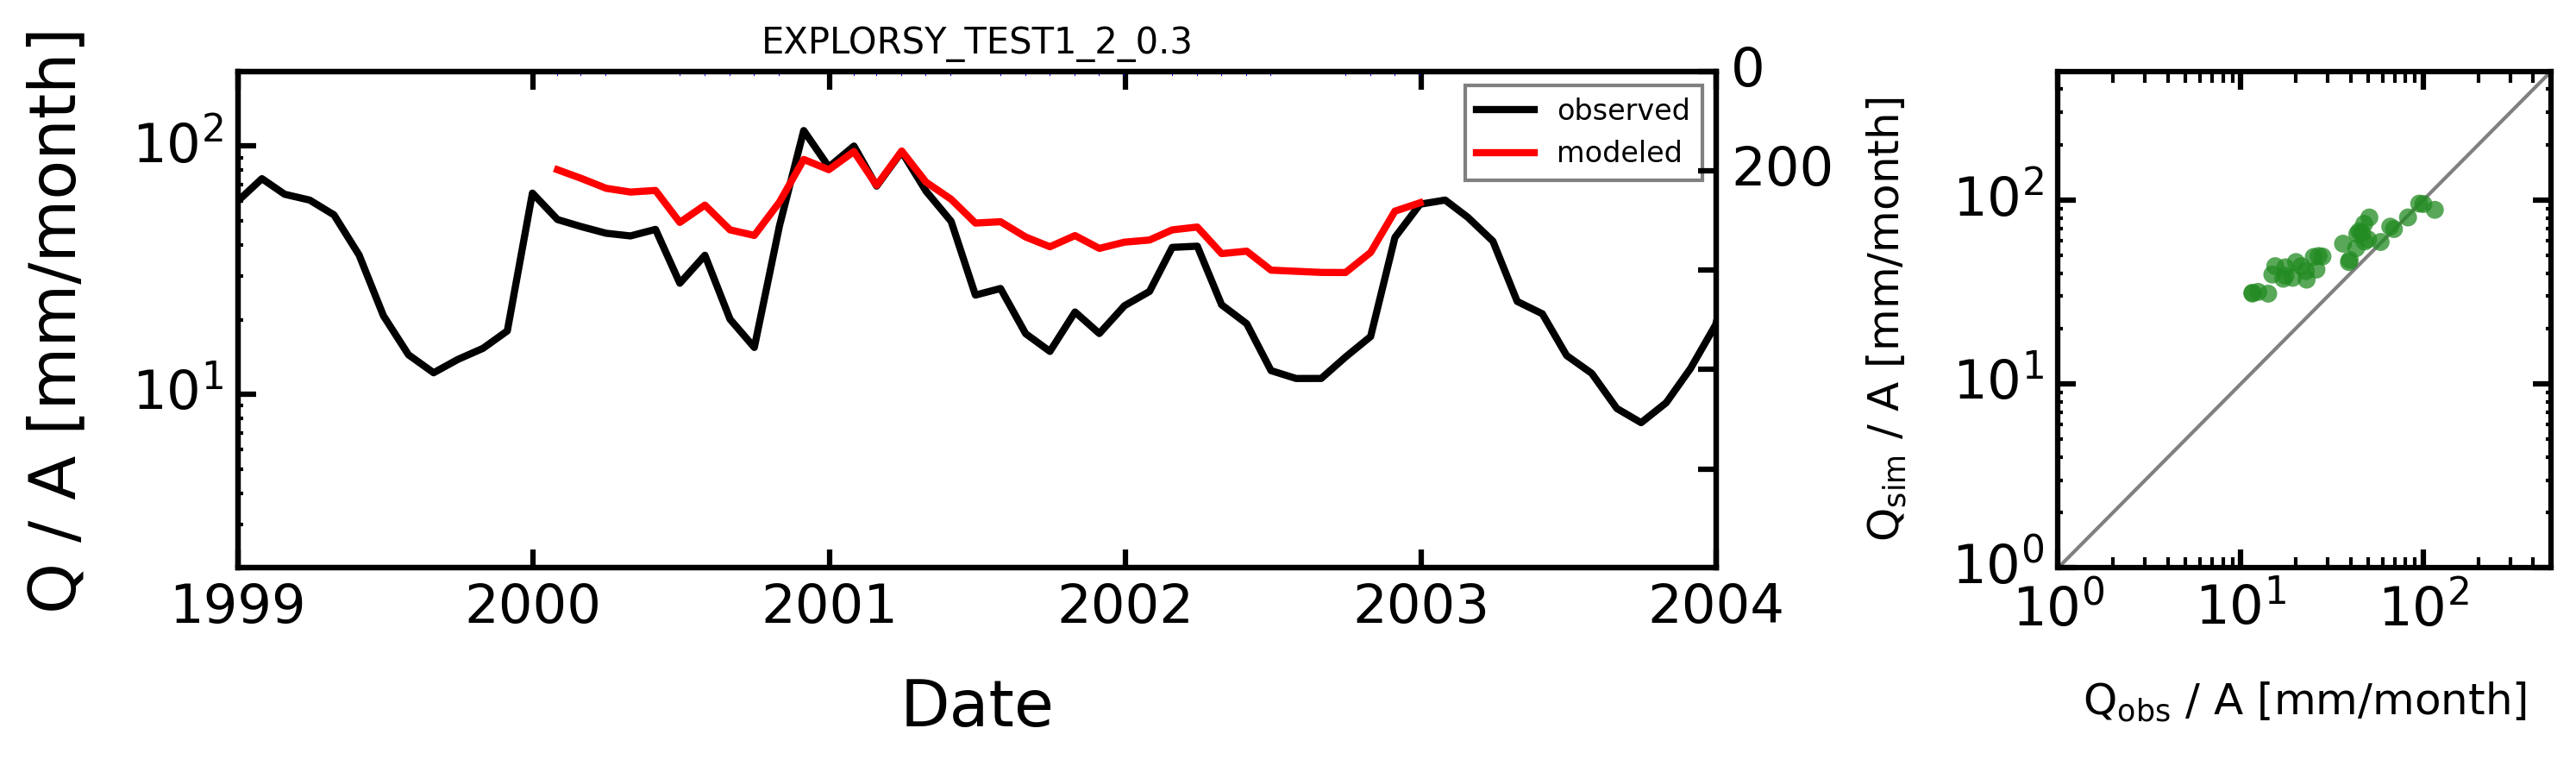

In [17]:

# iD_set_simulations = 'explorSy_mperday_monthly_steady'
# iD_set_simulations = 'explorSy_mperday_monthly_transient'
# iD_set_simulations = 'explorSy_mpermonth_monthly_transient'
# iD_set_simulations = 'explorSy_mpermonth_monthly_steady'


Qobs_path = os.path.join(data_path, 'hydrometry catchment Nancon.csv')
Qobs = pd.read_csv(Qobs_path, sep=';', index_col=0, parse_dates=True)

area = int(round(BV.geographic.area))
Qobs = (Qobs / (area*1000000)) * (3600 * 24) # m3/s to m/day
Qobs = Qobs.resample('M').sum() * 1000 # m/day to mm/month

simul_list = sorted(glob.glob(os.path.join(simulations_folder,
                                           iD_set_simulations+'*')),
                   key=os.path.getmtime)

for i, simul in enumerate(simul_list[:]):
    
    fig, (a0, a1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]},
                                 figsize=(10,3))

    model_name = os.path.split(simul)[-1]
        
    Smod_path = os.path.join(simul, 
                             r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)
    
    Qmod = Smod['outflow_drain'] 
    Qmod = Qmod.squeeze() * 1000
    Qmod = (Qmod + (r * 1000)) * Qmod.index.day
    
    Rmod = Smod['recharge'] * Qmod.index.day
    
    yearsmaj = mdates.YearLocator(1)   # every year
    yearsmin = mdates.YearLocator(1)
    # monthsmaj = mdates.MonthLocator(6)  # every month
    # monthsmin = mdates.MonthLocator(3)
    # months_fmt = mdates.DateFormatter('%m') #b = name of month ?
    years_fmt = mdates.DateFormatter('%Y')

    ax = a0
    ax.plot(Qobs, color='k', lw=2, ls='-', zorder=0, label='observed')
    ax.plot(Qmod, color='red', lw=2, label='modeled')
    # ax.plot(Rmod.index, Rmod*1000, color='blue', lw=2.5)
    ax.set_xlabel('Date')
    ax.set_ylabel('Q / A [mm/month]')
    ax.set_yscale('log')
    ax.set_ylim(2,200)
    ax.xaxis.set_major_locator(yearsmaj)
    ax.xaxis.set_minor_locator(yearsmin)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.set_xlim(pd.to_datetime('1999'), pd.to_datetime('2004'))
    ax.legend()
    ax.set_title(model_name.upper(), fontsize=10)
    
    axb = ax.twinx()
    axb.bar(Rmod.index, Rmod,color='blue', edgecolor='blue', lw=2.5)
    axb.set_ylim(0,999)
    axb.invert_yaxis()
    axb.set_yticklabels([0,200])
    
    Qobs_stat = select_period(Qobs,2000,2002)
    Qmod_stat = select_period(Qmod,2000,2002)
    
    import hydroeval as he
    NSE = he.evaluator(he.nse, Qmod_stat, Qobs_stat)[0]
    NSElog = he.evaluator(he.nse, Qmod_stat, Qobs_stat, transform='log')[0]
    RMSE = np.sqrt(np.nanmean((Qobs_stat.values-Qmod_stat.values)**2))
    KGE = he.evaluator(he.kge, Qmod_stat, Qobs_stat)[0][0]
    print(model_name.upper())
    print(round(NSE,2))
    print(round(NSElog,2))
    print(round(RMSE,2))
    print(round(KGE,2))
    
    ax = a1
    ax.scatter(Qobs_stat, Qmod_stat,
               s=25, edgecolor='none', alpha=0.75, facecolor='forestgreen')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.plot((0.1,1000),(0.1,1000), color='grey', zorder=-1)
    ax.set_xlim(1,500)
    ax.set_ylim(1,500)
    # ax.set_xlim(0.1,300)
    # ax.set_ylim(0.1,300)    
    ax.set_xlabel('$Q_{obs}$ / A [mm/month]', fontsize=12)
    ax.set_ylabel('$Q_{sim}$ / A [mm/month]', fontsize=12)

    fig.tight_layout()
                
    # fig.savefig(os.path.join(simulations_folder, '_figures',
    #             'STREAMFLOW_'+model_name+'.png'),
    #             bbox_inches='tight')



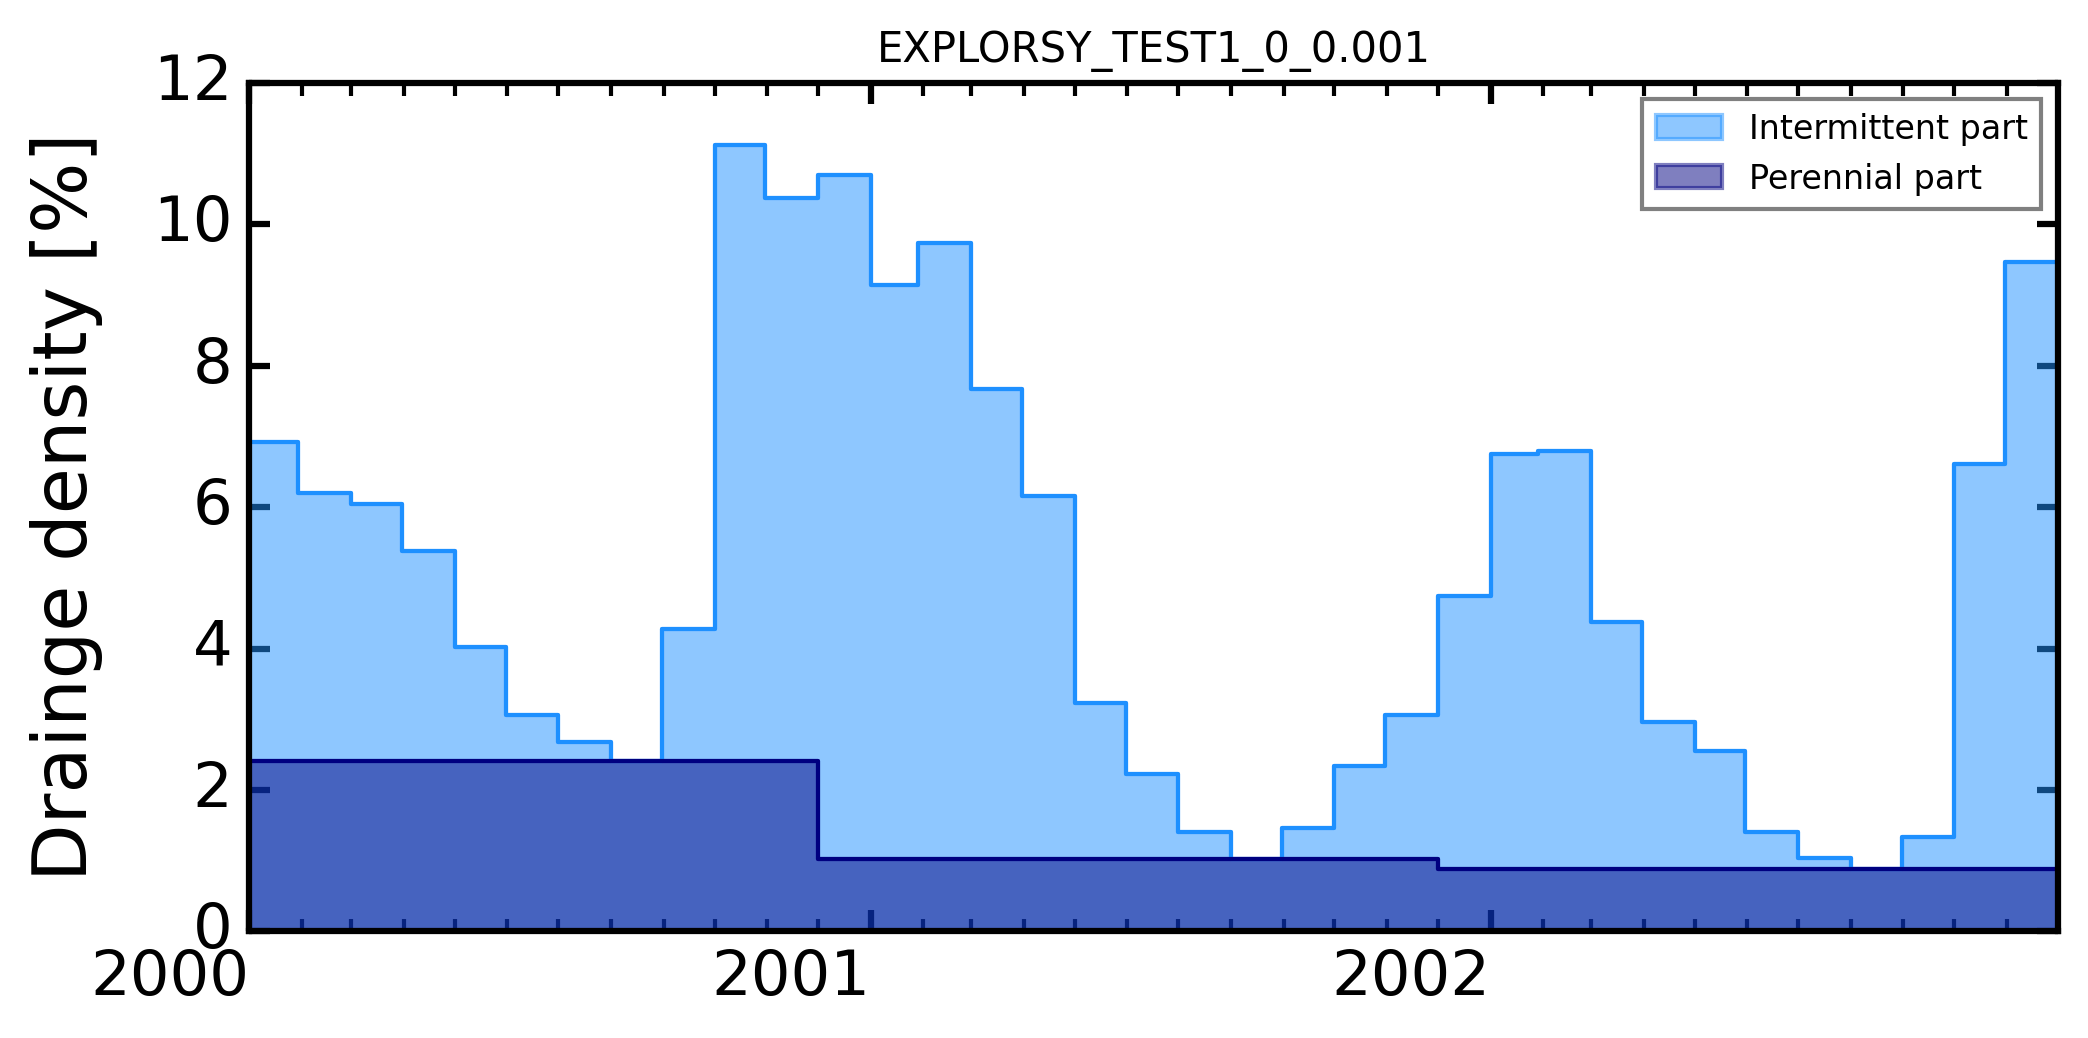

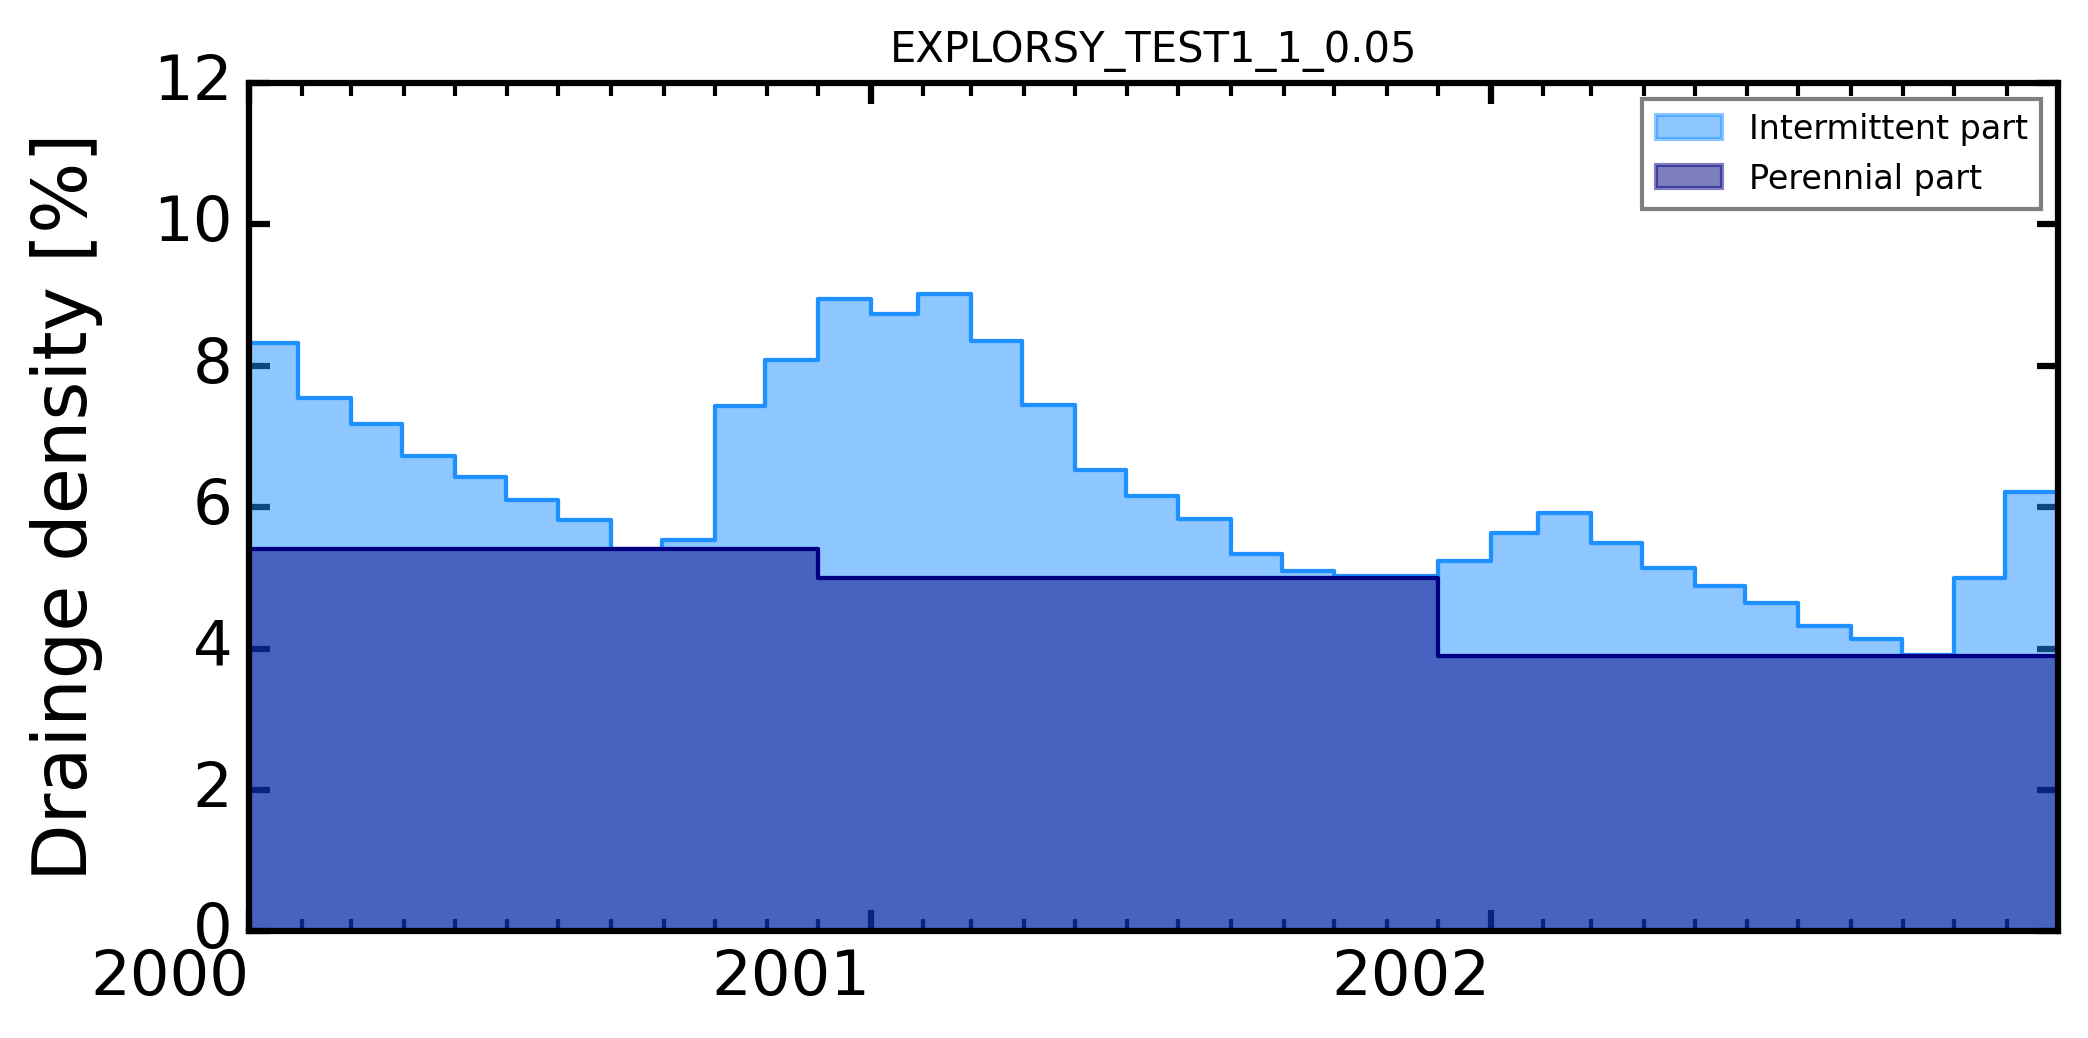

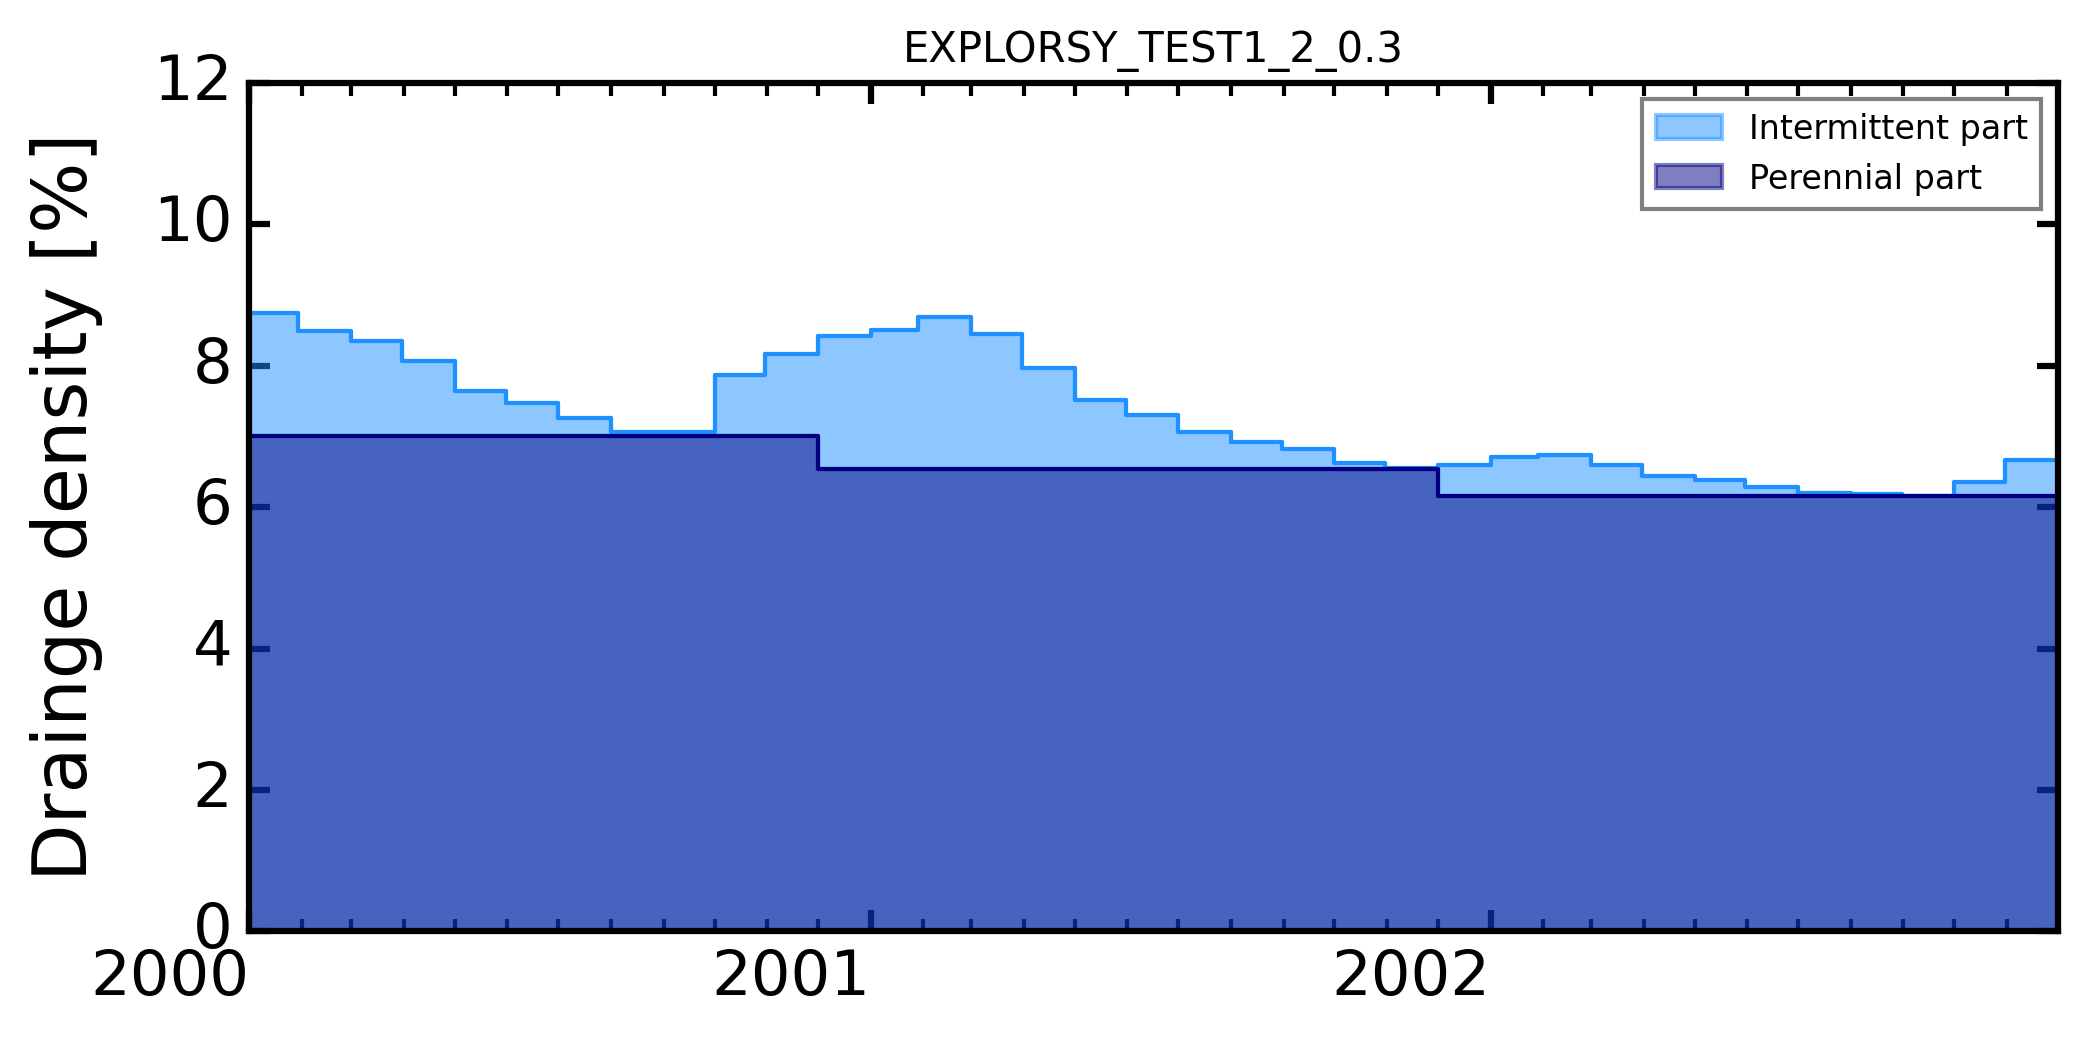

In [18]:

def select_period(df, first, last):
    df = df[(df.index.year>=first) & (df.index.year<=last)]
    return df

Qobs_path = os.path.join(data_path, 'hydrometry catchment Nancon.csv')
Qobs = pd.read_csv(Qobs_path, sep=';', index_col=0, parse_dates=True)

area = int(round(BV.geographic.area))
Qobs = (Qobs / (area*1000000)) * (3600 * 24) # m3/s to m/day
Qobs = Qobs.resample('M').sum() * 1000 # m/day to mm/month

simul_list = sorted(glob.glob(os.path.join(simulations_folder,
                                           iD_set_simulations+'*')),
                   key=os.path.getmtime)

for i, simul in enumerate(simul_list[:]):
    
    model_name = os.path.split(simul)[-1]
    
    Smod_path = os.path.join(simul, 
                             r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)
    
    Qmod = Smod['outflow_drain'] 
    Qmod = Qmod.squeeze() * 1000
    Qmod = Qmod + (r * 1000)
    
    Rmod = Smod['recharge'] * 1000
        
    Sonde_path = os.path.join(glob.glob(
        os.path.join(simul, r'_subbasins/intermittency_*'))[0],
        '_simulated_timeseries.csv')
    Sonde = pd.read_csv(Sonde_path, sep=';', index_col=0, parse_dates=True)

    # BV.add_intermittency(data_path, 'regional onde stations.shp')

    # d = BV.intermittency.flowing
    # assec = d[d==1].dropna()
    # invi = d[d==2].dropna()
    # low = d[d==3].dropna()
    # accep = d[d==4].dropna()
    # visib = d[d==5].dropna()
    # d = d.resample('M').mean()
    
    # Smod['onde'] = d
    
    from datetime import timedelta
    x_months = Smod.index + timedelta(days=-30)
    Smod['date'] = x_months
    Smod.index = Smod['date']
    
    fig, ax = plt.subplots(1, 1, figsize=(7,3.5))
    
    ax.fill_between(Smod.index, 0, Smod['total_areas'],
                    interpolate=False, color='dodgerblue', alpha=0.5,
                    step='pre', label='Intermittent part')
    ax.fill_between(Smod.index, 0, Smod['perenn_areas'],
                    interpolate=False, color='navy', alpha=0.5,
                    step='pre', label='Perennial part')
    ax.legend()
    ax.step(Smod.index, Smod['total_areas'], color='dodgerblue',
            marker=None, markeredgecolor='none',
            markersize=5, lw=1, label='upstream',
            where='pre')
    ax.step(Smod.index, Smod['perenn_areas'], color='navy',
            marker=None, markeredgecolor='none',
            markersize=5, lw=1, label='upstream',
            where='pre')

    ax.set_ylim(-0,12)
    # ax.set_yticks(np.arange(0,15.05,2.5))
    ax.set_ylabel('Drainge density [%]')
    ax.set_xlim(pd.to_datetime('2000-01'), pd.to_datetime('2002-12'))
    plt.xticks(rotation=0, ha="right")

    years_maj = mdates.YearLocator()   # every year
    months_maj = mdates.MonthLocator()  # every x month
    ax.xaxis.set_major_locator(years_maj)
    ax.xaxis.set_minor_locator(months_maj)
    
    ax.set_title(model_name.upper(), fontsize=10)
    
    fig.tight_layout()
                
    # fig.savefig(os.path.join(simulations_folder, '_figures',
    #             'SATURATION_'+model_name+'.png'),
    #             bbox_inches='tight')
                


In [19]:

os.chdir(root_dir)
